## Imports

In [1]:
import pandas as pd

from utility_processing import (
    quitar_asterisco,
    crear_lista_diccionarios,
    plot_metric,
    comparar_metricas,
    crear_datagramas_filtrados,
    crear_tabla_comparativa_para_formatos,
    crear_tabla_comparativa_para_modelos_yolo,
    crear_tabla_promedios_modelos_yolo,
    crear_tabla_promedios_dataset,
    crear_tablas_mejora_tiempos,
    guardar_figura
)

In [2]:
results_path_1 = "training/results_1.csv"
results_path_2 = "training/results_2.csv"

# Read both CSV files
df1 = pd.read_csv(results_path_1)   # Sin transfer Learning
df2 = pd.read_csv(results_path_2)   # Con transfer Learning

# Concatenate them into a single DataFrame
df = pd.concat([df1, df2], ignore_index=True)
df["total_time"] = df["preprocess"] + df["inference"] + df["postprocess"]
df["FPS"] = 1000/df["inference"]
df["FPS_total"] = 1000/df["total_time"]

In [3]:
# Lista de modelos
modelos_yolov8 = ["yolov8n-seg", "yolov8n-seg*" "yolov8s-seg", "yolov8s-seg*", "yolov8m-seg",
                  "yolov8m-seg*", "yolov8l-seg", "yolov8l-seg*", "yolov8x-seg", "yolov8x-seg*"]
modelos_yolov9 = ["yolov9c-seg", "yolov9c-seg*", "yolov9e-seg", "yolov9e-seg*"]
modelos_yolo11 = ["yolo11n-seg", "yolo11n-seg*", "yolo11s-seg", "yolo11s-seg*", "yolo11m-seg",
                  "yolo11m-seg*", "yolo11l-seg", "yolo11l-seg*", "yolo11x-seg", "yolo11x-seg*"]

# Lista de modelos sin transfer learning
modelos_fl = ["yolov8n-seg", "yolov8s-seg","yolov8m-seg", "yolov8l-seg", "yolov8x-seg",
              "yolov9c-seg","yolov9e-seg", "yolo11n-seg", "yolo11s-seg", "yolo11m-seg",
              "yolo11l-seg", "yolo11x-seg"]

# Lista de modelos con transfer learning
modelos_tl = ["yolov8n-seg*", "yolov8s-seg*","yolov8m-seg*", "yolov8l-seg*", "yolov8x-seg*",
              "yolov9c-seg*","yolov9e-seg*","yolo11n-seg*", "yolo11s-seg*", "yolo11m-seg*",
              "yolo11l-seg*", "yolo11x-seg*"]

# Lista de ordenes
orden_yolov8 = ["yolov8n-seg", "yolov8s-seg", "yolov8m-seg", "yolov8l-seg", "yolov8x-seg"]
orden_yolov9 = ["yolov9c-seg", "yolov9e-seg"]
orden_yolo11 = ["yolo11n-seg", "yolo11s-seg", "yolo11m-seg", "yolo11l-seg", "yolo11x-seg"]
models_by_size = ["yolo11n-seg", "yolov8n-seg", "yolo11s-seg", "yolov8s-seg", "yolo11m-seg", "yolov8m-seg",
                  "yolov9c-seg", "yolo11l-seg", "yolov8l-seg", "yolov9e-seg", "yolo11x-seg", "yolov8x-seg"]
model_by_version = ["yolov8n-seg", "yolov8s-seg", "yolov8m-seg", "yolov8l-seg", "yolov8x-seg", "yolov9c-seg",
                    "yolov9e-seg", "yolo11n-seg", "yolo11s-seg", "yolo11m-seg", "yolo11l-seg", "yolo11x-seg"]

# Comparar datos

## Comparar según tamaño de modelo
Acá se busca ver que efecto tiene el tamaño del modelo en la calidad del mismo, además se trata de ver el efecto del uso de Transfer Learning (congelar capas al momento de entrenar). Para esto se agrupan los datos según su versión: YOLOv8, YOLOv9 y YOLO11. Además se exluyen los casos de modelos exportados (Format != Pytorch). Se pueden analizar los modelos enternados con Transfer Learning, sin Transfer Learning o ambos juntos.

### Creamos los diferentes datagramas a usar

In [4]:
# Datagrama solo con casos en formato Pytorch
df_pytorch = df[df["Format"].isin(["Pytorch"])].copy()
df_tensor32 = df[df["Format"].isin(["TensorRT-F32"])].copy()
df_tensor16 = df[df["Format"].isin(["TensorRT-F16"])].copy()
df_tensor8 = df[df["Format"].isin(["TensorRT-INT8"])].copy()

# Con Transfer Learning
df_pytorch_tl = quitar_asterisco(df_pytorch, modelos_tl)
df_tensor8_tl = quitar_asterisco(df_tensor8, modelos_tl)
# Sin Transfer Learning
df_pytorch_fl = quitar_asterisco(df_pytorch, modelos_fl)
df_tensor8_fl = quitar_asterisco(df_tensor8, modelos_fl)
# Ambos casos
df_pytorch_tt = quitar_asterisco(df_pytorch, modelos_tl+modelos_fl)
df_tensor32_tt = quitar_asterisco(df_tensor32, modelos_tl+modelos_fl)
df_tensor16_tt = quitar_asterisco(df_tensor16, modelos_tl+modelos_fl)
df_tensor8_tt = quitar_asterisco(df_tensor8, modelos_tl+modelos_fl)

# Versiones sin outliers
df_pytorch_tt_thr = df_pytorch_tt[df_pytorch_tt["F1_score(M)"] >= 0.6]
df_pytorch_fl_thr = df_pytorch_fl[df_pytorch_fl["F1_score(M)"] >= 0.6]
df_pytorch_tl_thr = df_pytorch_tl[df_pytorch_tl["F1_score(M)"] >= 0.6]
df_tensor32_tt_thr = df_tensor32_tt[df_tensor32_tt["F1_score(M)"] >= 0.6]
df_tensor16_tt_thr = df_tensor16_tt[df_tensor16_tt["F1_score(M)"] >= 0.6]
df_tensor8_tt_thr = df_tensor8_tt[df_tensor8_tt["F1_score(M)"] >= 0.6]
df_tensor8_fl_thr = df_tensor8_fl[df_tensor8_fl["F1_score(M)"] >= 0.6]
df_tensor8_tl_thr = df_tensor8_tl[df_tensor8_tl["F1_score(M)"] >= 0.6]

# Otros más
df_fl = quitar_asterisco(df, modelos_fl)
df_fl["TransferLearning"] = False 
df_tl = quitar_asterisco(df, modelos_tl)
df_tl["TransferLearning"] = True

df_updated = pd.concat([df_fl, df_tl])
df_updated["Model"] = df_updated["Model"].str.replace("*", "", regex=False)

In [5]:
datagram = [df_pytorch_tt_thr]
datagrams = [df_pytorch_tl_thr, df_pytorch_fl_thr]
group = ["Model"]
groups = ["Model", "Model"]
metrics = ["F1_score(M)", "mAP50(M)", "mAP50-95(M)"]
labels = ["Con Transfer Learning", "Sin Transfer Learning"]
xlabel = "Modelo"
ylabel = ["F1_score(M)", "mAP50(M)", "mAP50-95(M)"]
figsize = (7, 3)
fontsize = 12

### Por Modelo

#### YOLOv8

In [6]:
order = orden_yolov8
label = ["YOLOv8"]
plot_dict_yolov8 = crear_lista_diccionarios(datagram, datagrams, group, groups, metrics, label, labels, order, xlabel, ylabel, figsize=figsize)

##### F1_score(M)

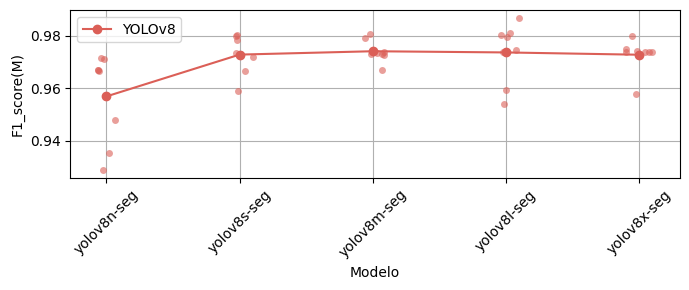

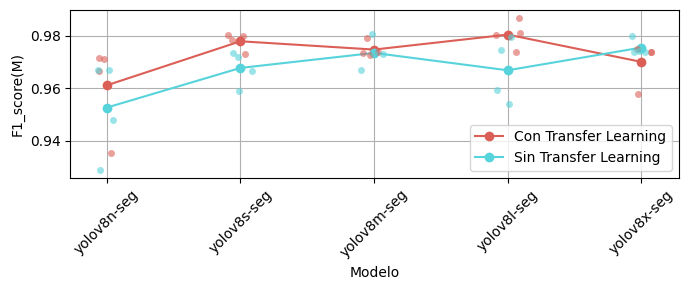

In [7]:
figuras_yolov8_f1score = [plot_metric(**plot_dict_yolov8[0]), plot_metric(**plot_dict_yolov8[1])]

##### mAP50(M)

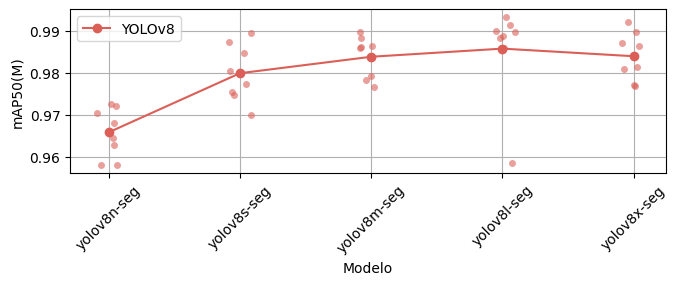

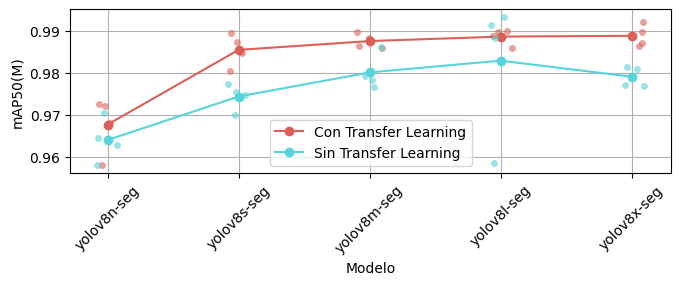

In [8]:
figuras_yolov8_map50 = [plot_metric(**plot_dict_yolov8[2]), plot_metric(**plot_dict_yolov8[3])]

##### mAP50-95(M)

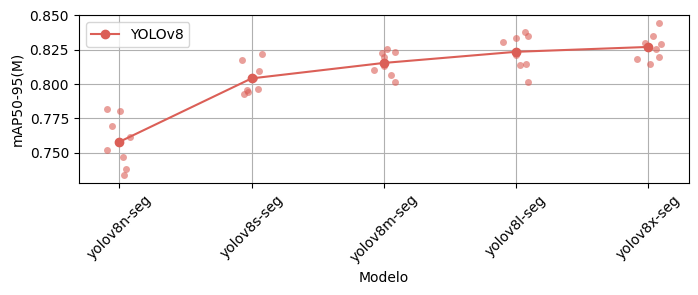

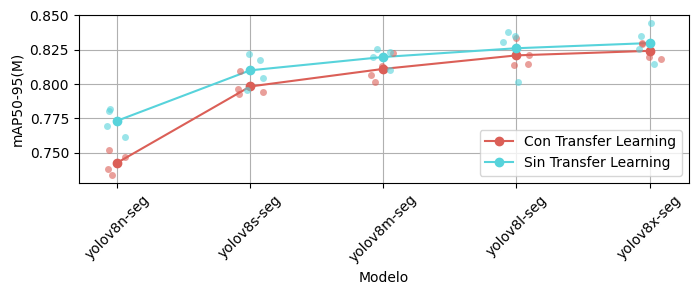

In [9]:
figuras_yolov8_map5095 = [plot_metric(**plot_dict_yolov8[4]), plot_metric(**plot_dict_yolov8[5])]

#### YOLOv9

In [10]:
order = orden_yolov9
label = ["YOLOv9"]

plot_dict_yolov9 = crear_lista_diccionarios(datagram, datagrams, group, groups, metrics, label, labels, order, xlabel, ylabel, figsize=figsize)

##### F1_score(M)

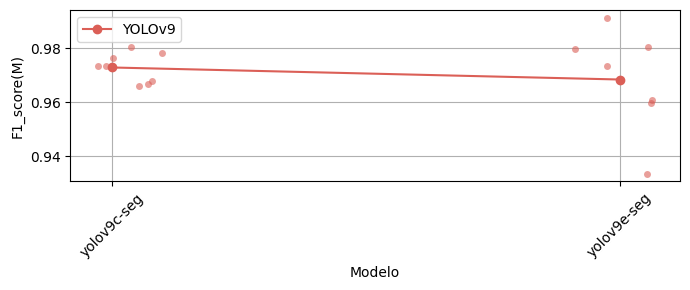

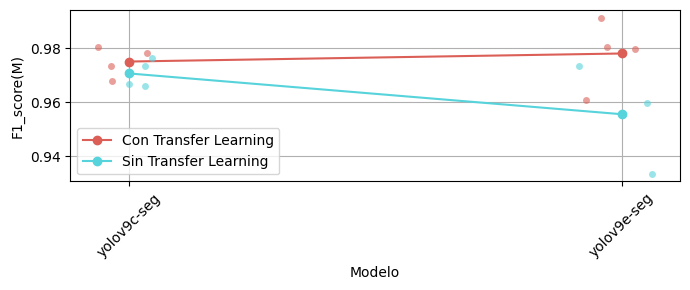

In [11]:
figuras_yolov9_f1score = [plot_metric(**plot_dict_yolov9[0]), plot_metric(**plot_dict_yolov9[1])]

##### mAP50(M)

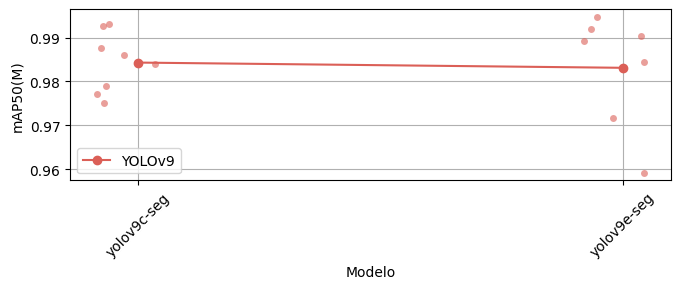

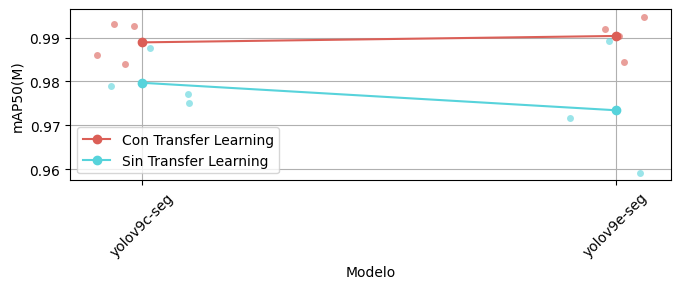

In [12]:
figuras_yolov9_map50 = [plot_metric(**plot_dict_yolov9[2]), plot_metric(**plot_dict_yolov9[3])]

##### mAP50-95(M)

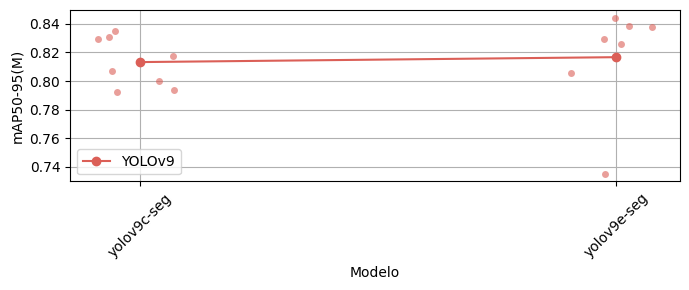

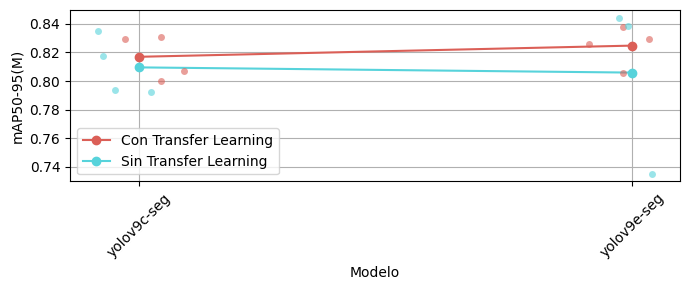

In [13]:
figuras_yolov9_map5095 = [plot_metric(**plot_dict_yolov9[4]), plot_metric(**plot_dict_yolov9[5])]

#### YOLO11

In [14]:
order = orden_yolo11
label = ["YOLO11"]

plot_dict_yolo11 = crear_lista_diccionarios(datagram, datagrams, group, groups, metrics, label, labels, order, xlabel, ylabel, figsize=figsize)

##### F1_score(M)

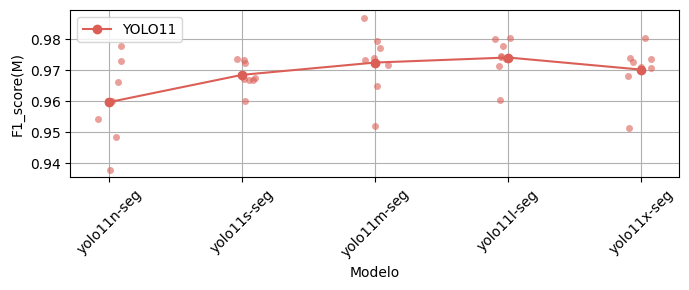

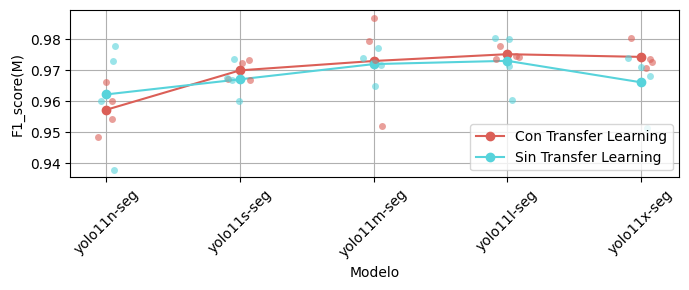

In [15]:
figuras_yolo11_f1score = [plot_metric(**plot_dict_yolo11[0]), plot_metric(**plot_dict_yolo11[1])]

##### mAP50(M)

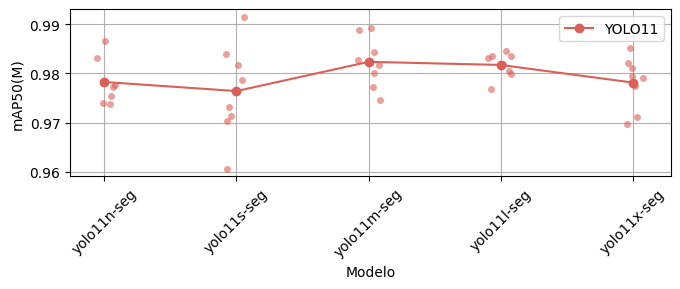

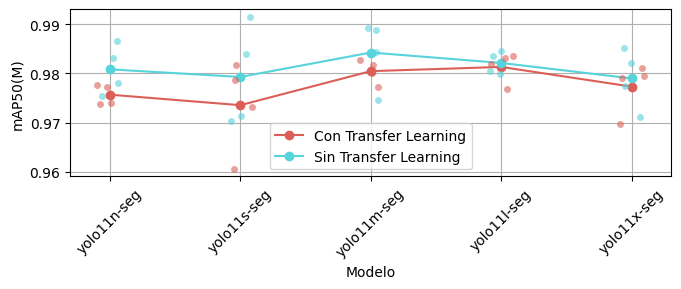

In [16]:
figuras_yolo11_map50 = [plot_metric(**plot_dict_yolo11[2]), plot_metric(**plot_dict_yolo11[3])]

##### mAP50-95(M)

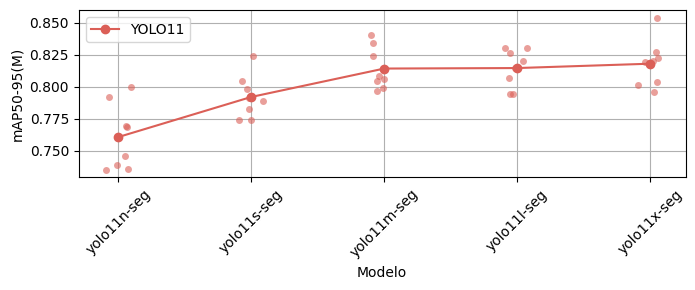

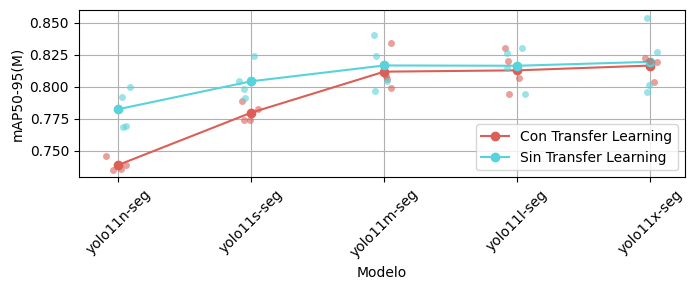

In [17]:
figuras_yolo11_map5095 = [plot_metric(**plot_dict_yolo11[4]), plot_metric(**plot_dict_yolo11[5])]

### Todos juntos

In [18]:
order = models_by_size
label = ["Promedio"]
#figsize = (10, 4)
plot_dict_yolo_todos = crear_lista_diccionarios(datagram, datagrams, group, groups, metrics, label, labels, order, xlabel, ylabel)

#### F1_score(M)

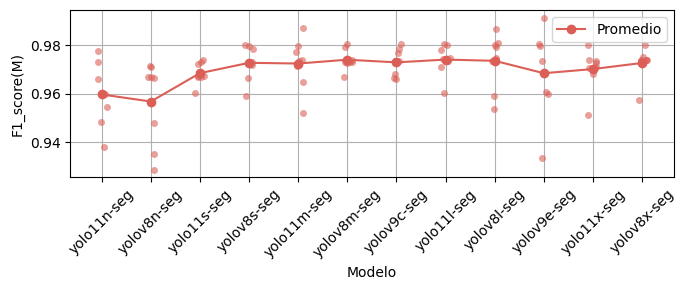

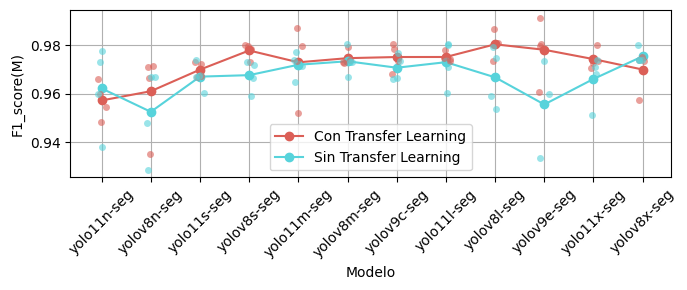

In [19]:
figuras_yolo_f1score = [plot_metric(**plot_dict_yolo_todos[0]), plot_metric(**plot_dict_yolo_todos[1])]

#### mAP50(M)

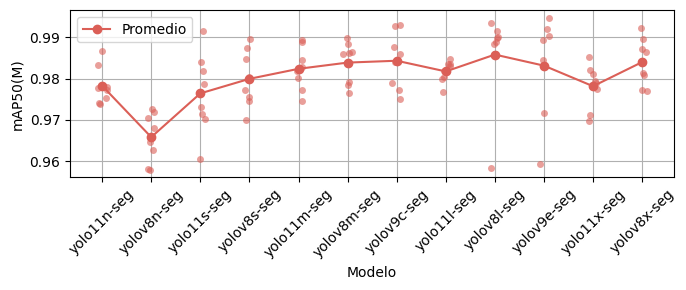

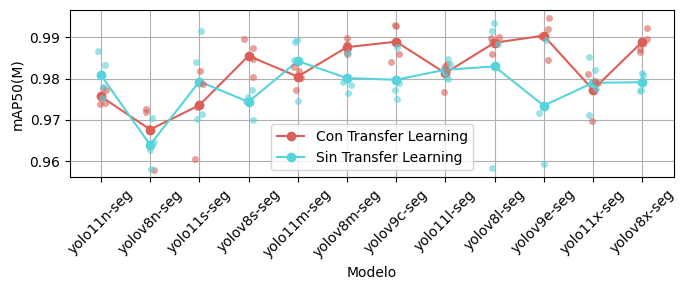

In [20]:
figuras_yolo_map50 = [plot_metric(**plot_dict_yolo_todos[2]), plot_metric(**plot_dict_yolo_todos[3])]

#### mAP50-90(M)

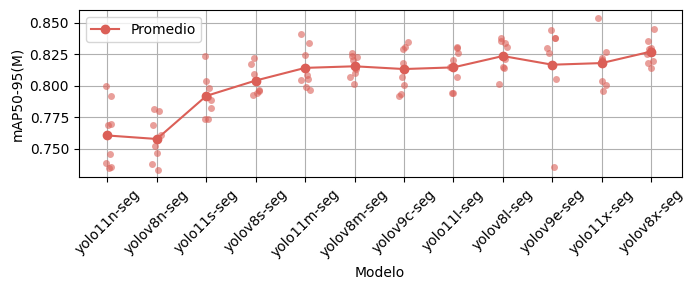

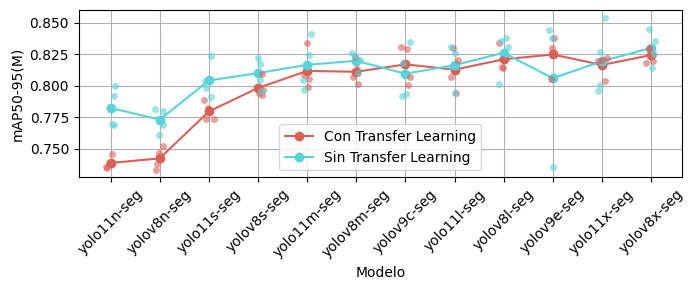

In [21]:
figuras_yolo_map5095 = [plot_metric(**plot_dict_yolo_todos[4]), plot_metric(**plot_dict_yolo_todos[5])]

### Comparar por Formato (Todos)

In [22]:
datagram = [df_pytorch_tt_thr]
datagrams = [df_pytorch_tt_thr, df_tensor32_tt_thr, df_tensor16_tt_thr, df_tensor8_tt_thr]
group = ["Model"]
groups = ["Model", "Model", "Model", "Model"]
metrics = ["F1_score(M)", "mAP50(M)", "mAP50-95(M)"]
labels = ["Pytorch", "Float32", "Float16", "INT8"]
xlabel = "Modelo"
ylabel = ["F1_score(M)", "mAP50(M)", "mAP50-95(M)"]
order = models_by_size
label = ["Promedio"]

plot_dict_yolo_todos_format = crear_lista_diccionarios(datagram, datagrams, group, groups, metrics, label, labels, order, xlabel, ylabel)

##### F1_score(M)

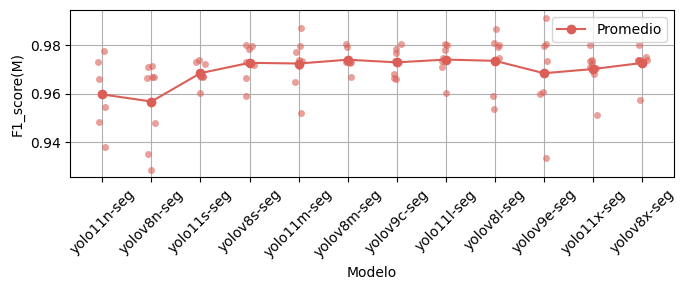

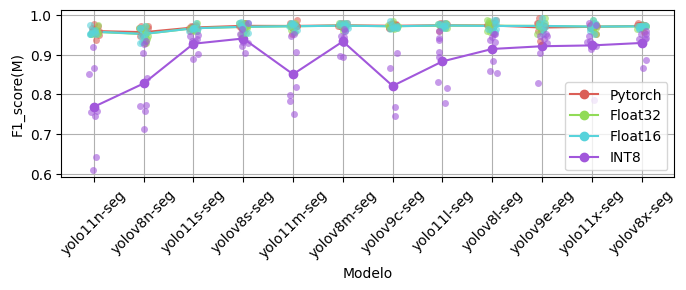

In [23]:
figuras_yolo_format_f1score = [plot_metric(**plot_dict_yolo_todos_format[0]), plot_metric(**plot_dict_yolo_todos_format[1])]

##### mAP50(M)

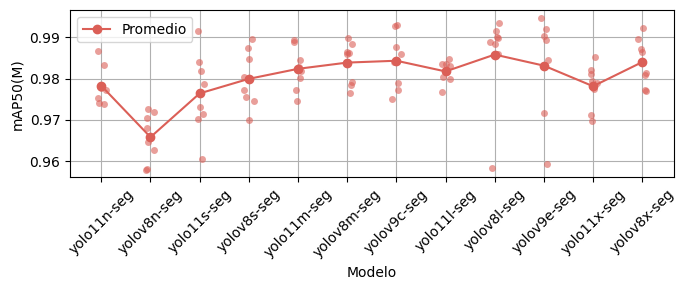

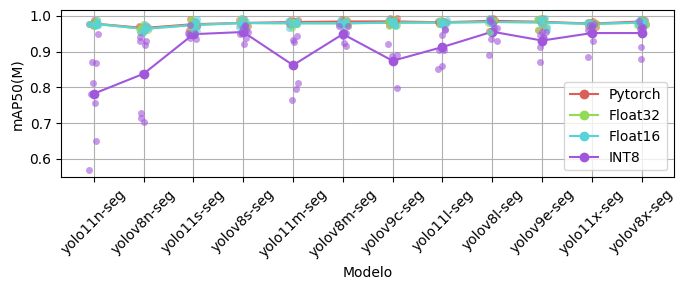

In [24]:
figuras_yolo_format_map50 = [plot_metric(**plot_dict_yolo_todos_format[2]), plot_metric(**plot_dict_yolo_todos_format[3])]

##### mAP50-95(M)

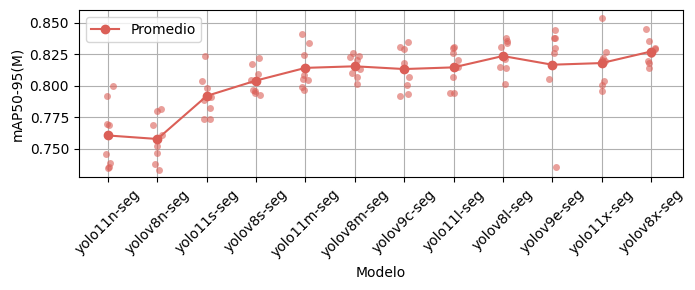

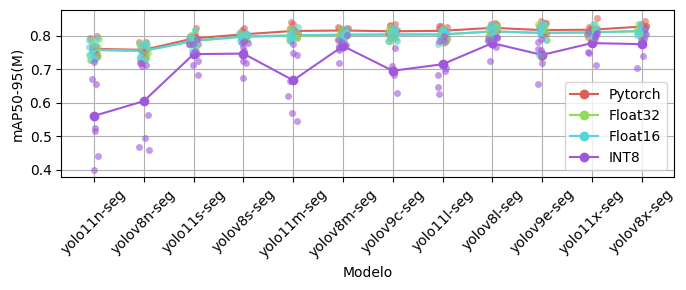

In [25]:
figuras_yolo_format_map5095 = [plot_metric(**plot_dict_yolo_todos_format[4]), plot_metric(**plot_dict_yolo_todos_format[5])]

### Comparar por Formato (Con y sin Transfer Learning)

In [26]:
datagram = [df_pytorch_tt_thr]
datagrams = [df_tensor8_tl, df_tensor8_fl]
group = ["Model"]
groups = ["Model", "Model"]
metrics = ["F1_score(M)", "mAP50(M)", "mAP50-95(M)"]
labels = ["Con Transfer Learning", "Sin Transfer Learning"]
xlabel = "Modelo"
ylabel = ["F1_score(M)", "mAP50(M)", "mAP50-95(M)"]
order = models_by_size
label = ["Promedio"]
title = None #"Resultados con exportación TensorRT-INT8"

plot_dict_yolo_todos_int8_tl = crear_lista_diccionarios(datagram, datagrams, group, groups, metrics, label, labels, order, xlabel, ylabel, title)

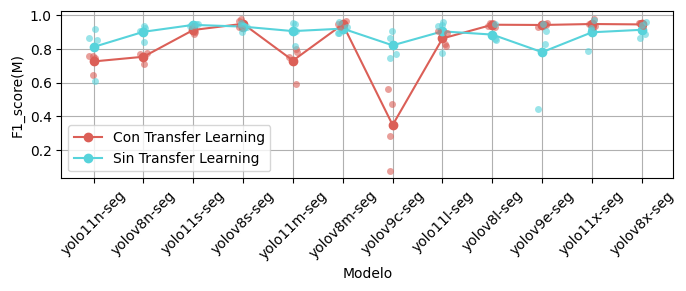

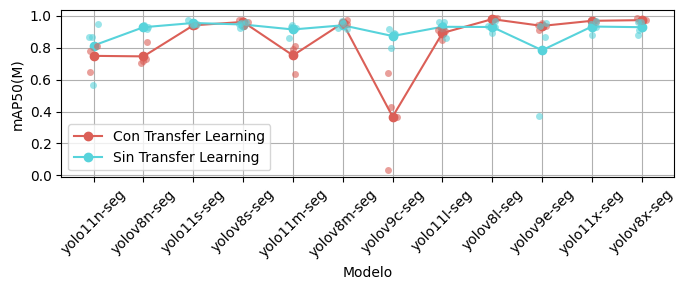

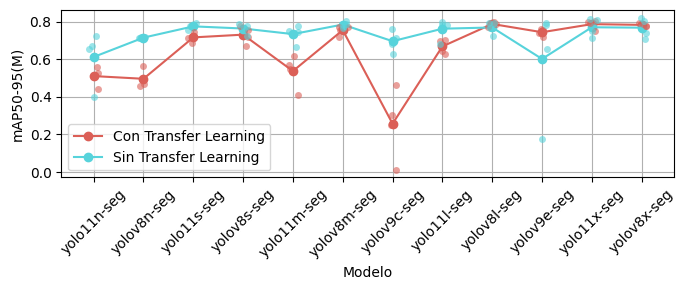

In [27]:
figuras_yolo__todos_int8_map5095 = [plot_metric(**plot_dict_yolo_todos_int8_tl[1]), plot_metric(**plot_dict_yolo_todos_int8_tl[3]), plot_metric(**plot_dict_yolo_todos_int8_tl[5])]

### Conclusiones de comparación según tamaño de modelo:

1) El tamaño del modelo afecta solo un poco en el rendimiento de la tarea de segmentación. Se obtienen mejores rendimientos al aumentar el tamaño del modelo pero la ganancia es cada vez más pequeña. Es posible que esto se deba a que el Dataset Deepfish no es tan complejo.
2) Respecto al efecto del uso de Transfer Learning: no parece ser que exista mucha diferencia. En teoría el en entrenamiento con Transfer Learning debiese dar peores resultados pero no parece ser el caso siempre, al menos no con este dataset y lo entrenamientos realizados hasta ahora. Si se ve una diferencia más notoria con la métrica mAP50-95. Más adelante se analizará el efecto de TL en la exportación del modelo.

### Comparar según optimizador

### Tablas con diferencias

Se comparará el rendimiento de SGD y AdamW para determinar cual es mejor, en promedio. Las metricas a evaluar son F1_score(M), mAP50(M), mAP50-95(M) y fitness. Se separarán en varios casos:
1) Promedio global.
3) Promedio por versión de modelo.
4) Promedio por modelo específico.

Para cada caso además se realizarán las siguientes variantes.
1. Incluyendo y excluyendo exportaciones.
2. Incluyendo y excluyendo outliers (casos muy malos de AdamW).

In [28]:
# Datagrama sin asteriscos Combinados totales (la unica diff con df es el asterisco)
df_tt = df_updated.copy()
df_tt["Model"] = df_tt["Model"].str.replace("*", "", regex=False)

# Datagrama solo con casos de optimizador SGD y AdamW
df_SGD = df_tt[df_tt["Optimizer"].isin(["SGD"])].copy().reset_index(drop=True)
df_AdamW = df_tt[df_tt["Optimizer"].isin(["AdamW"])].copy().reset_index(drop=True)

# Parametros para comparar
columna_1 = "Format"
columna_2 = "Model"
opciones_1 = ["Pytorch", "TensorRT-F32", "TensorRT-F16", "TensorRT-INT8"]
opciones_2 = models_by_size
casos_a_comparar = ["AdamW", "SGD"]

# Comparar por Formato
resultados_1 = comparar_metricas(datagrama=df_updated, columna="Optimizer", casos_a_comparar=casos_a_comparar)
mean_diff_by_format, mean_diff_r_by_format, mean_diff_m_by_format, mean_diff_re_by_format = crear_datagramas_filtrados(resultados_1, columna_1, opciones_1)

# Comparar por Modelo
resultados_2 = comparar_metricas(datagrama=df_tt, columna="Optimizer", casos_a_comparar=casos_a_comparar)
diff_df_all, diff_df_thr, mejora_rel_df_all, mejora_rel_df_thr, factor_df_all, factor_df_thr, reduccion_error_df_all, reduccion_error_df_thr = resultados_2
mean_diff_by_model, mean_diff_r_by_model, mean_diff_m_by_model, mean_diff_re_by_model = crear_datagramas_filtrados(resultados_2, columna_2, opciones_2, orden=model_by_version)

#### Comparación por formato

In [29]:
print("Diferencia entre SGD y AdamW, por formato de exportación.")
mean_diff_by_format[["F1_score(M)", "mAP50(M)", "mAP50-95(M)", "fitness", "Format", "Outlier"]].reset_index(drop=True)

Diferencia entre SGD y AdamW, por formato de exportación.


,F1_score(M),mAP50(M),mAP50-95(M),fitness,Format,Outlier
0,0.011670,0.012532,0.026392,0.062887,Pytorch,True
1,0.010353,0.011609,0.025808,0.060774,TensorRT-F32,True
2,0.010262,0.011299,0.025527,0.061034,TensorRT-F16,True
3,0.059605,0.046529,0.056070,0.131731,TensorRT-INT8,True
4,0.022973,0.020492,0.033449,0.079107,Todos,True
5,0.002843,0.002568,0.014580,0.038919,Pytorch,False
6,0.001156,0.001916,0.014072,0.036977,TensorRT-F32,False
7,0.001048,0.001599,0.013764,0.037205,TensorRT-F16,False
8,0.033488,0.018396,0.031053,0.083192,TensorRT-INT8,False
9,0.009247,0.005921,0.018162,0.048520,Todos,False


In [30]:
print("Diferencia porcentual entre SGD y AdamW, por formato de exportación.")
mean_diff_r_by_format[["F1_score(M)", "mAP50(M)", "mAP50-95(M)", "fitness", "inference", "Format", "Outlier"]].reset_index(drop=True)

Diferencia porcentual entre SGD y AdamW, por formato de exportación.


,F1_score(M),mAP50(M),mAP50-95(M),fitness,inference,Format,Outlier
0,1.204861,1.285064,3.150865,3.654581,-7.451531,Pytorch,True
1,1.060565,1.192997,3.118798,3.560540,-0.254064,TensorRT-F32,True
2,1.050998,1.161587,3.079823,3.572486,0.268170,TensorRT-F16,True
3,7.560116,5.988688,8.619207,9.620688,-0.336738,TensorRT-INT8,True
4,2.719135,2.407084,4.492173,5.102074,-1.943541,Todos,True
5,0.284971,0.259614,1.741527,2.265545,-7.677743,Pytorch,False
6,0.111689,0.193442,1.712864,2.179535,-0.294263,TensorRT-F32,False
7,0.100667,0.161268,1.672257,2.190478,0.228405,TensorRT-F16,False
8,3.413782,1.601629,3.645466,4.914053,-0.495176,TensorRT-INT8,False
9,0.938275,0.537000,2.169476,2.854538,-2.085065,Todos,False


In [31]:
# TODO: Datos importantes!!
print("Factor de mejora entre SGD y AdamW, por formato de exportación.")
mean_diff_m_by_format[["F1_score(M)", "mAP50(M)", "mAP50-95(M)", "fitness", "inference", "Format", "Outlier"]].reset_index(drop=True)

Factor de mejora entre SGD y AdamW, por formato de exportación.


,F1_score(M),mAP50(M),mAP50-95(M),fitness,inference,Format,Outlier
0,1.019664,1.023022,1.065295,1.069620,1.360668,Pytorch,True
1,1.018741,1.021350,1.064378,1.067604,0.997710,TensorRT-F32,True
2,1.018684,1.021035,1.064082,1.067863,1.003023,TensorRT-F16,True
3,1.197823,1.312258,1.629470,1.456000,0.997372,TensorRT-INT8,True
4,1.063728,1.094416,1.205806,1.165272,1.089693,Todos,True
5,1.003064,1.002672,1.018452,1.023878,1.367643,Pytorch,False
6,1.001264,1.002028,1.017949,1.022844,0.997308,TensorRT-F32,False
7,1.001163,1.001703,1.017562,1.022981,1.002623,TensorRT-F16,False
8,1.043069,1.025606,1.050564,1.063557,0.995788,TensorRT-INT8,False
9,1.011638,1.007717,1.025736,1.032824,1.092382,Todos,False


In [32]:
print("Reducción del loss entre SGD y AdamW, por formato de exportación.")
mean_diff_re_by_format[["loss", "Format", "Outlier"]].reset_index(drop=True)

Reducción del loss entre SGD y AdamW, por formato de exportación.


,loss,Format,Outlier
0,-0.501617,Pytorch,True
1,-0.015315,TensorRT-F32,True
2,0.004467,TensorRT-F16,True
3,-0.052942,TensorRT-INT8,True
4,-0.141352,Todos,True
5,-0.517388,Pytorch,False
6,-0.015035,TensorRT-F32,False
7,0.004240,TensorRT-F16,False
8,-0.040142,TensorRT-INT8,False
9,-0.143735,Todos,False


#### Comparación por modelo

In [33]:
print("Diferencia entre SGD y AdamW, por modelo.")
mean_diff_by_model[["F1_score(M)", "mAP50(M)", "mAP50-95(M)", "fitness", "Model", "Outlier"]].reset_index(drop=True)

Diferencia entre SGD y AdamW, por modelo.


,F1_score(M),mAP50(M),mAP50-95(M),fitness,Model,Outlier
0,-0.001184,-0.002619,-0.006198,-0.004308,yolov8n-seg,True
1,0.004602,0.004760,0.012597,0.038892,yolov8s-seg,True
2,0.010524,0.006805,0.014634,0.046616,yolov8m-seg,True
3,0.000509,0.007311,0.016557,0.048452,yolov8l-seg,True
4,0.008705,0.006050,0.020703,0.051891,yolov8x-seg,True
5,0.042304,0.040167,0.046096,0.107537,yolov9c-seg,True
6,0.129587,0.137742,0.181246,0.370506,yolov9e-seg,True
7,0.015642,0.009481,0.011383,0.016622,yolo11n-seg,True
8,-0.001372,0.001578,0.016184,0.048472,yolo11s-seg,True
9,0.019674,0.015557,0.035334,0.079684,yolo11m-seg,True


In [34]:
print("Diferencia porcentual entre SGD y AdamW, por modelo.")
mean_diff_r_by_model[["F1_score(M)", "mAP50(M)", "mAP50-95(M)", "fitness", "Model", "Outlier"]].reset_index(drop=True)

Diferencia porcentual entre SGD y AdamW, por modelo.


,F1_score(M),mAP50(M),mAP50-95(M),fitness,Model,Outlier
0,-0.118384,-0.509298,-1.163910,-0.479060,yolov8n-seg,True
1,0.473649,0.491003,1.621557,2.385512,yolov8s-seg,True
2,1.098723,0.704762,1.835552,2.823918,yolov8m-seg,True
3,0.079369,0.757621,2.022024,2.873625,yolov8l-seg,True
4,0.914567,0.631329,2.529749,3.090352,yolov8x-seg,True
5,8.323852,8.125861,10.570113,11.163839,yolov9c-seg,True
6,13.491196,14.258415,22.041890,21.873218,yolov9e-seg,True
7,1.363209,0.471770,0.891150,0.465365,yolo11n-seg,True
8,-0.143334,0.162083,2.073526,3.007112,yolo11s-seg,True
9,2.268335,1.792212,4.965890,5.322469,yolo11m-seg,True


In [35]:
print("Factor de mejora entre SGD y AdamW, por modelo.")
mean_diff_m_by_model[["F1_score(M)", "mAP50(M)", "mAP50-95(M)", "fitness", "Model", "Outlier"]].reset_index(drop=True)

Factor de mejora entre SGD y AdamW, por modelo.


,F1_score(M),mAP50(M),mAP50-95(M),fitness,Model,Outlier
0,0.999595,0.996728,0.991077,0.996931,yolov8n-seg,True
1,1.005038,1.005029,1.016931,1.024661,yolov8s-seg,True
2,1.011508,1.007392,1.018924,1.029426,yolov8m-seg,True
3,1.001610,1.008062,1.021283,1.030417,yolov8l-seg,True
4,1.010017,1.007074,1.027507,1.033648,yolov8x-seg,True
5,1.381746,1.750736,2.521247,1.999406,yolov9c-seg,True
6,1.244021,1.288042,1.684751,1.650670,yolov9e-seg,True
7,1.026289,1.024629,1.035037,1.029001,yolo11n-seg,True
8,0.998795,1.001717,1.021508,1.031302,yolo11s-seg,True
9,1.030245,1.022112,1.061866,1.064201,yolo11m-seg,True


In [36]:
print("Reducción del loss entre SGD y AdamW, por modelo.")
mean_diff_re_by_model[["loss", "Model", "Outlier"]].reset_index(drop=True)

Reducción del loss entre SGD y AdamW, por modelo.


,loss,Model,Outlier
0,0.000369,yolov8n-seg,True
1,-0.081818,yolov8s-seg,True
2,-0.554145,yolov8m-seg,True
3,-0.049752,yolov8l-seg,True
4,-0.061512,yolov8x-seg,True
5,0.039025,yolov9c-seg,True
6,-0.033300,yolov9e-seg,True
7,-0.736238,yolo11n-seg,True
8,-0.080839,yolo11s-seg,True
9,-0.014702,yolo11m-seg,True


### Con gráficos - Comparación simple

Se visualizan los rendimientos de SGD y AdamW en gráficos donde se muestran las métricas a comparar y sus diferencias.

In [37]:
datagram = [mean_diff_m_by_model]
datagrams = [df_SGD[df_SGD["F1_score(M)"]>=0.6], df_AdamW[df_AdamW["F1_score(M)"]>=0.6]]
group = ["Model"]
groups = ["Model", "Model"]
metrics = ["F1_score(M)", "mAP50(M)", "mAP50-95(M)"]
labels = ["SGD", "AdamW"]
xlabel = "Modelo"
ylabel = metrics

#### YOLOv8

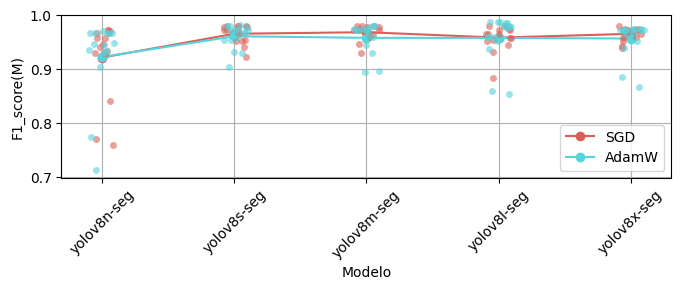

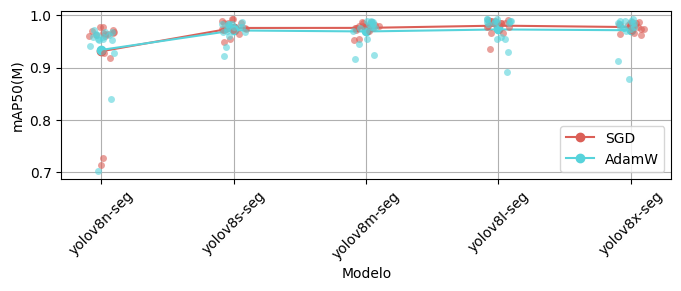

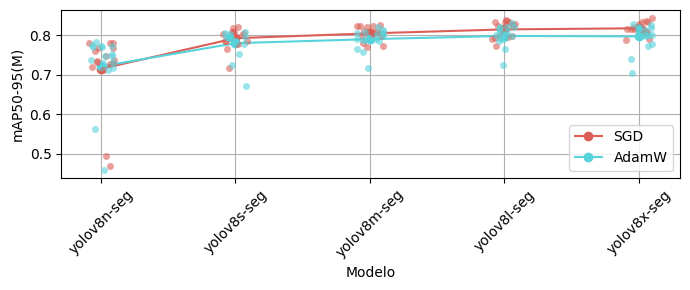

In [38]:
order = orden_yolov8
label = ["YOLOv8"]
plot_dict_yolov8_opt_simple = crear_lista_diccionarios(datagram, datagrams, group, groups, metrics, label, labels, order, xlabel, ylabel)
figuras_yolov8_opt_simple = [plot_metric(**plot_dict_yolov8_opt_simple[1]), plot_metric(**plot_dict_yolov8_opt_simple[3]), plot_metric(**plot_dict_yolov8_opt_simple[5])]

#### YOLOv9

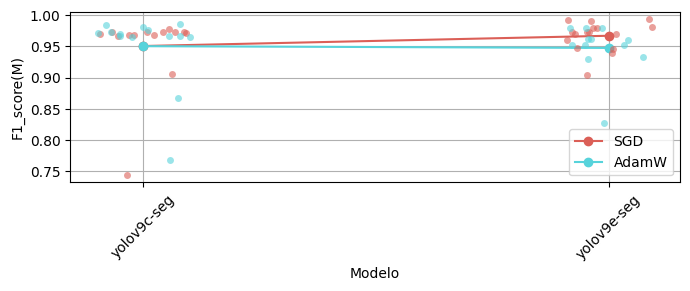

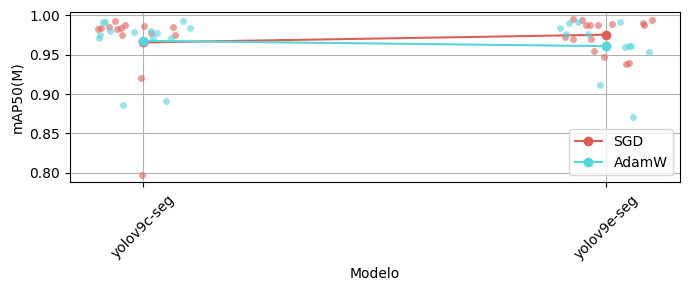

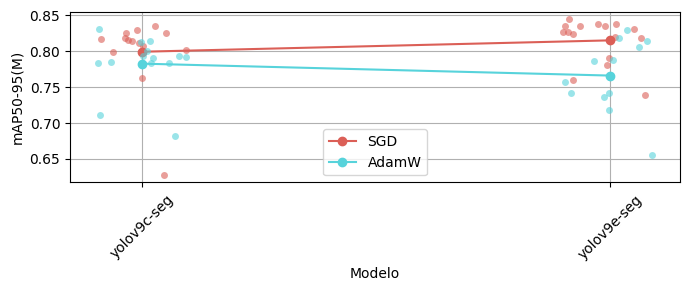

In [39]:
order = orden_yolov9
label = ["YOLOv9"]
plot_dict_yolov9_opt_simple = crear_lista_diccionarios(datagram, datagrams, group, groups, metrics, label, labels, order, xlabel, ylabel)
figuras_yolov9_opt_simple = [plot_metric(**plot_dict_yolov9_opt_simple[1]), plot_metric(**plot_dict_yolov9_opt_simple[3]), plot_metric(**plot_dict_yolov9_opt_simple[5])]

#### YOLO11

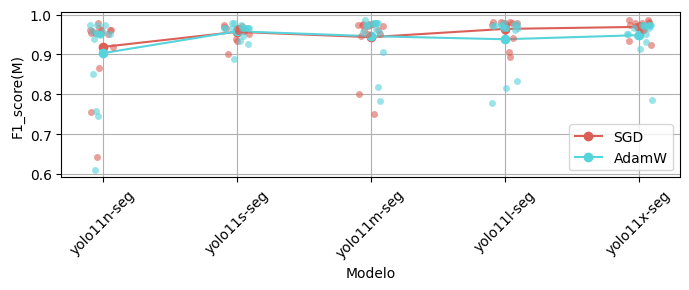

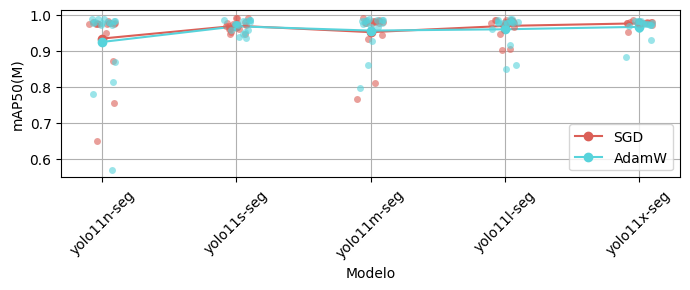

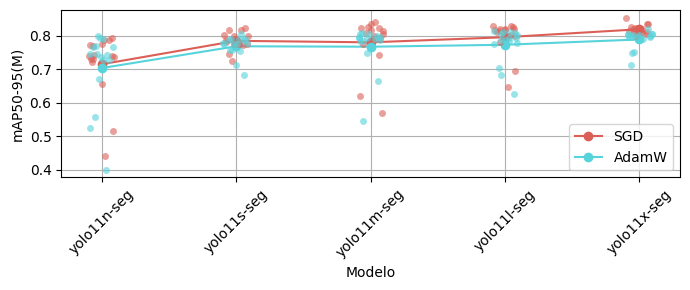

In [40]:
order = orden_yolo11
label = ["YOLO11"]
plot_dict_yolo11_opt_simple = crear_lista_diccionarios(datagram, datagrams, group, groups, metrics, label, labels, order, xlabel, ylabel)
figuras_yolo11_opt_simple = [plot_metric(**plot_dict_yolo11_opt_simple[1]), plot_metric(**plot_dict_yolo11_opt_simple[3]), plot_metric(**plot_dict_yolo11_opt_simple[5])]

#### Todos juntos

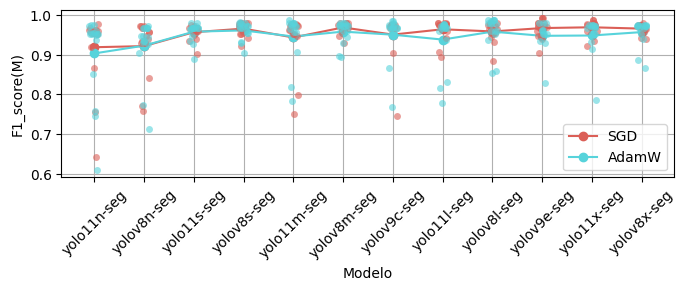

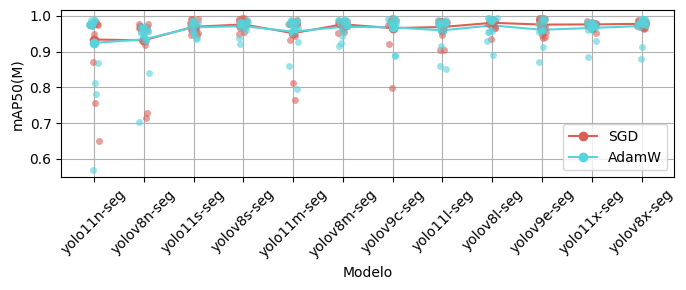

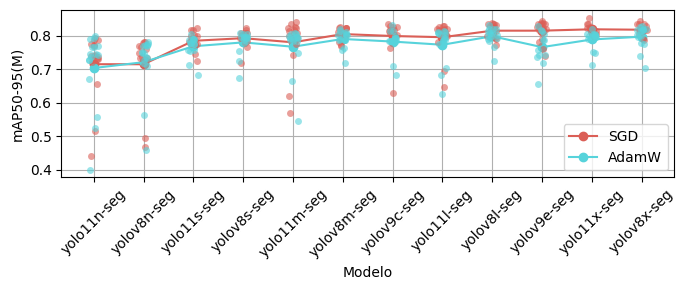

In [41]:
order = models_by_size
label = ["Promedio"]
plot_dict_yolo_opt_simple = crear_lista_diccionarios(datagram, datagrams, group, groups, metrics, label, labels, order, xlabel, ylabel)
figuras_yolo_opt_simple = [plot_metric(**plot_dict_yolo_opt_simple[1]), plot_metric(**plot_dict_yolo_opt_simple[3]), plot_metric(**plot_dict_yolo_opt_simple[5])]

### Con gráficos - Comparación factor de mejora

In [42]:
datagram = [mean_diff_m_by_model[mean_diff_m_by_model["Outlier"]==False]]
datagrams = [mean_diff_m_by_model[mean_diff_m_by_model["Outlier"]==False], mean_diff_m_by_model[mean_diff_m_by_model["Outlier"]==True]]
group = ["Model"]
groups = ["Model", "Model"]
metrics = ["F1_score(M)", "mAP50(M)", "mAP50-95(M)"]
labels = ["Sin Outliers", "Con Outliers"]
xlabel = "Modelo"
ylabel = [r"$\Delta_{rel}$ F1_score(M)", r"$\Delta_{rel}$ mAP50(M)", r"$\Delta_{rel}$ mAP50-95(M)"]
title = None #"Factor de mejora entre SGD y AdamW."

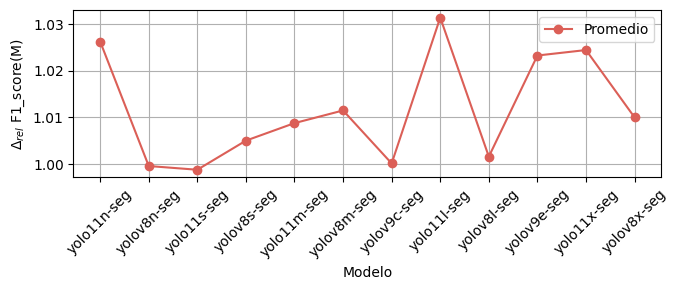

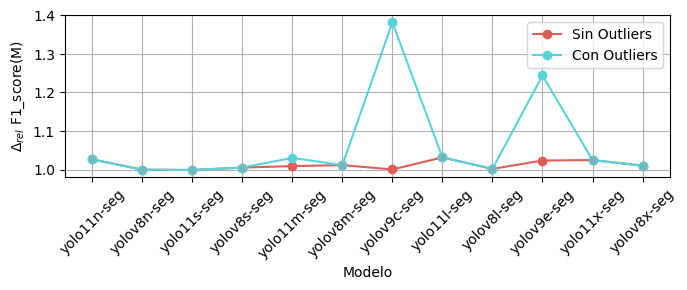

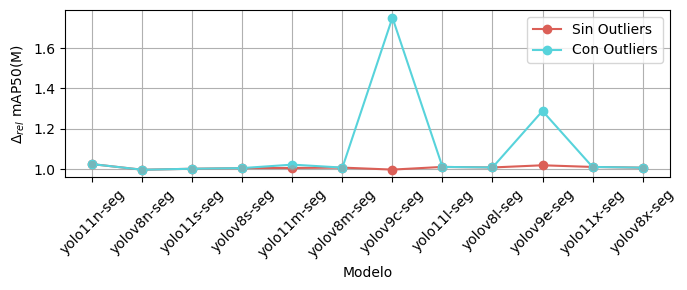

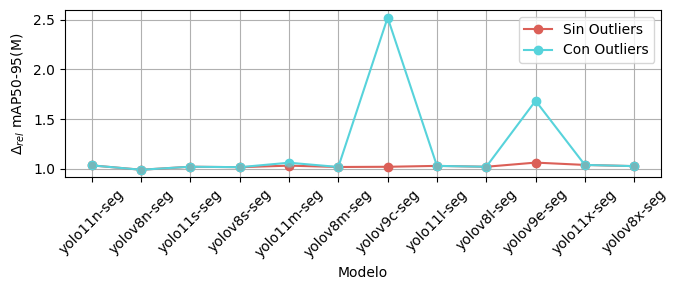

In [43]:
# TODO: Datos importantes!!!
order = models_by_size
label = ["Promedio"]
plot_dict_yolo11_opt_diffm = crear_lista_diccionarios(datagram, datagrams, group, groups, metrics, label, labels, order, xlabel, ylabel, title)
figuras_yolo11_opt_diffm = [plot_metric(**plot_dict_yolo11_opt_diffm[0]), plot_metric(**plot_dict_yolo11_opt_diffm[1]), plot_metric(**plot_dict_yolo11_opt_diffm[3]), plot_metric(**plot_dict_yolo11_opt_diffm[5])]

## Conclusiones de comparación según optimizador:

1) SGD es ligeramente superior a AdamW.
2) La diferencia entre SGD y AdamW se hace mayor al realizar exportación en TensorRT con cuantización númerica.
3) AdamW tiene mayor tendencia a fallar en el entrenamiento (casos outliers) lo que lo hace menos fiable.

## Efecto de la exportación
Se vieron algunos efectos de la exportación antes, pero ahora se mostrarán los efectos más directos.

### Tablas comparativas

In [44]:
# Parametros para comparar
columnas_1 = "Model"
columnas_2 = "Format"
opciones_1 = model_by_version
opciones_2 = ["Pytorch",  "TensorRT-F32", "TensorRT-F16", "TensorRT-INT8"]
casos_a_comparar_1 = ["Pytorch", "TensorRT-F32"]
casos_a_comparar_2 = ["Pytorch", "TensorRT-F16"]
casos_a_comparar_3 = ["Pytorch", "TensorRT-INT8"]
casos_a_comparar_4 = [False, True]

# Comparar por Modelo
resultados_tt_1 = comparar_metricas(datagrama=df_updated, columna="Format", casos_a_comparar=casos_a_comparar_1)
resultados_tt_2 = comparar_metricas(datagrama=df_updated, columna="Format", casos_a_comparar=casos_a_comparar_2)
resultados_tt_3 = comparar_metricas(datagrama=df_updated, columna="Format", casos_a_comparar=casos_a_comparar_3)
mean_diff_by_format_tt_1, mean_diff_r_by_format_tt_1, mean_diff_m_by_format_tt_1, mean_diff_re_by_format_tt_1 = crear_datagramas_filtrados(resultados_tt_1, columnas_1, opciones_1)
mean_diff_by_format_tt_2, mean_diff_r_by_format_tt_2, mean_diff_m_by_format_tt_2, mean_diff_re_by_format_tt_2 = crear_datagramas_filtrados(resultados_tt_2, columnas_1, opciones_1)
mean_diff_by_format_tt_3, mean_diff_r_by_format_tt_3, mean_diff_m_by_format_tt_3, mean_diff_re_by_format_tt_3 = crear_datagramas_filtrados(resultados_tt_3, columnas_1, opciones_1)

# Comparar por Modelo (sin transfer learning)
resultados_fl_1 = comparar_metricas(datagrama=df_fl, columna="Format", casos_a_comparar=casos_a_comparar_1)
resultados_fl_2 = comparar_metricas(datagrama=df_fl, columna="Format", casos_a_comparar=casos_a_comparar_2)
resultados_fl_3 = comparar_metricas(datagrama=df_fl, columna="Format", casos_a_comparar=casos_a_comparar_3)
mean_diff_by_format_fl_1, mean_diff_r_by_format_fl_1, mean_diff_m_by_format_fl_1, mean_diff_re_by_format_fl_1 = crear_datagramas_filtrados(resultados_fl_1, columnas_1, opciones_1)
mean_diff_by_format_fl_2, mean_diff_r_by_format_fl_2, mean_diff_m_by_format_fl_2, mean_diff_re_by_format_fl_2 = crear_datagramas_filtrados(resultados_fl_2, columnas_1, opciones_1)
mean_diff_by_format_fl_3, mean_diff_r_by_format_fl_3, mean_diff_m_by_format_fl_3, mean_diff_re_by_format_fl_3 = crear_datagramas_filtrados(resultados_fl_3, columnas_1, opciones_1)

# Comparar por Modelo (con transfer learning)
resultados_tl_1 = comparar_metricas(datagrama=df_tl, columna="Format", casos_a_comparar=casos_a_comparar_1)
resultados_tl_2 = comparar_metricas(datagrama=df_tl, columna="Format", casos_a_comparar=casos_a_comparar_2)
resultados_tl_3 = comparar_metricas(datagrama=df_tl, columna="Format", casos_a_comparar=casos_a_comparar_3)
mean_diff_by_format_tl_1, mean_diff_r_by_format_tl_1, mean_diff_m_by_format_tl_1, mean_diff_re_by_format_tl_1 = crear_datagramas_filtrados(resultados_tl_1, columnas_1, opciones_1)
mean_diff_by_format_tl_2, mean_diff_r_by_format_tl_2, mean_diff_m_by_format_tl_2, mean_diff_re_by_format_tl_2 = crear_datagramas_filtrados(resultados_tl_2, columnas_1, opciones_1)
mean_diff_by_format_tl_3, mean_diff_r_by_format_tl_3, mean_diff_m_by_format_tl_3, mean_diff_re_by_format_tl_3 = crear_datagramas_filtrados(resultados_tl_3, columnas_1, opciones_1)

# Comparar por transfer learning
resultados_caso = comparar_metricas(datagrama=df_updated, columna="TransferLearning", casos_a_comparar=casos_a_comparar_4)
mean_diff_by_TL, mean_diff_r_by_TL, mean_diff_m_by_TL, mean_diff_re_by_TL = crear_datagramas_filtrados(resultados_caso, columnas_2, opciones_2)

In [45]:
print("Mejora relativa entre Pytorch y TensorRT")
crear_tabla_comparativa_para_formatos(mean_diff_m_by_format_tt_1, mean_diff_m_by_format_tt_2, mean_diff_m_by_format_tt_3)

Mejora relativa entre Pytorch y TensorRT


,F1_score(M),mAP50(M),mAP50-95(M),fitness,preprocess,inference,postprocess,Format
0,0.998918,0.997428,0.988555,0.990178,0.514364,1.324265,1.769501,TensorRT-F32
0,0.998980,0.997606,0.989441,0.990703,0.543204,0.491259,1.828118,TensorRT-F16
0,0.917626,0.929447,0.888295,0.880387,0.568437,0.359059,1.628565,TensorRT-INT8


In [46]:
print("Mejora relativa entre Pytorch y TensorRT (con Transfer Learning)")
crear_tabla_comparativa_para_formatos(mean_diff_m_by_format_tl_1, mean_diff_m_by_format_tl_2, mean_diff_m_by_format_tl_3)

Mejora relativa entre Pytorch y TensorRT (con Transfer Learning)


,F1_score(M),mAP50(M),mAP50-95(M),fitness,preprocess,inference,postprocess,Format
0,0.998582,0.996960,0.985508,0.987412,0.523253,1.359228,1.826870,TensorRT-F32
0,0.998645,0.996979,0.986316,0.987898,0.562532,0.505975,1.834869,TensorRT-F16
0,0.910096,0.919125,0.860261,0.857837,0.572541,0.377774,1.716184,TensorRT-INT8


### Con gráficos - Caso promedio (sin outliers)

In [47]:
datagram_1 = [mean_diff_m_by_format_tt_1]
datagram_2 = [mean_diff_m_by_format_fl_1]
datagram_3 = [mean_diff_m_by_format_tl_1]
datagrams_1 = [mean_diff_m_by_format_tt_1[mean_diff_m_by_format_tt_1["Outlier"]==False],
               mean_diff_m_by_format_tt_2[mean_diff_m_by_format_tt_2["Outlier"]==False],
               mean_diff_m_by_format_tt_3[mean_diff_m_by_format_tt_3["Outlier"]==False]]
datagrams_2 = [mean_diff_m_by_format_fl_1,
               mean_diff_m_by_format_fl_2,
               mean_diff_m_by_format_fl_3]
datagrams_3 = [mean_diff_m_by_format_tl_1,
               mean_diff_m_by_format_tl_2,
               mean_diff_m_by_format_tl_3]
group = ["Model"]
groups = ["Model", "Model", "Model"]
metrics = ["F1_score(M)", "mAP50(M)", "mAP50-95(M)"]
labels = ["Float32", "Float16", "INT8"]
xlabel = "Modelo"
ylabel = [r"$\Delta_{rel}$ F1_score(M)", r"$\Delta_{rel}$ mAP50(M)", r"$\Delta_{rel}$ mAP50-95(M)"]

order = models_by_size
label = ["Promedio"]
title_1 = None #"Factor de mejora entre Pytorch y TensorRT"
title_2 = None #"Factor de mejora entre Pytorch y TensorRT, sin Transfer Learning"
title_3 = None #"Factor de mejora entre Pytorch y TensorRT, con Transfer Learning"

plot_dict_yolo_format_ft_diffm = crear_lista_diccionarios(datagram_1, datagrams_1, group, groups, metrics, label, labels, order, xlabel, ylabel, title_1)
plot_dict_yolo_format_fl_diffm = crear_lista_diccionarios(datagram_2, datagrams_2, group, groups, metrics, label, labels, order, xlabel, ylabel, title_2)
plot_dict_yolo_format_tl_diffm = crear_lista_diccionarios(datagram_3, datagrams_3, group, groups, metrics, label, labels, order, xlabel, ylabel, title_3)

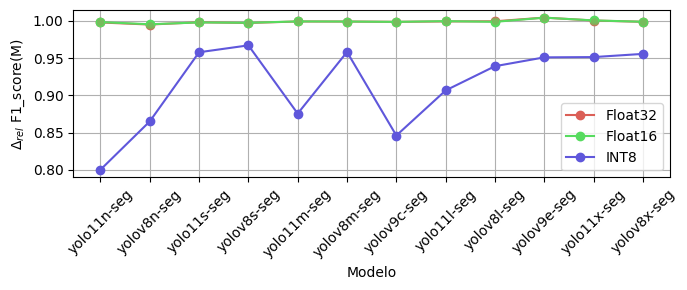

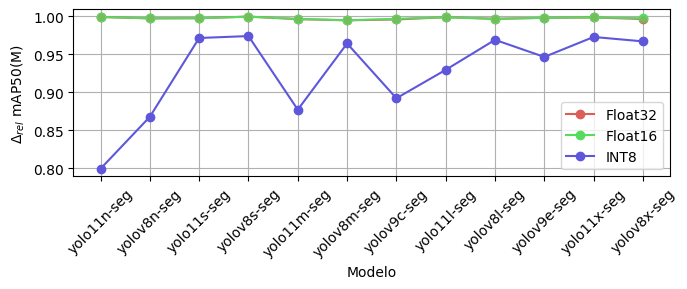

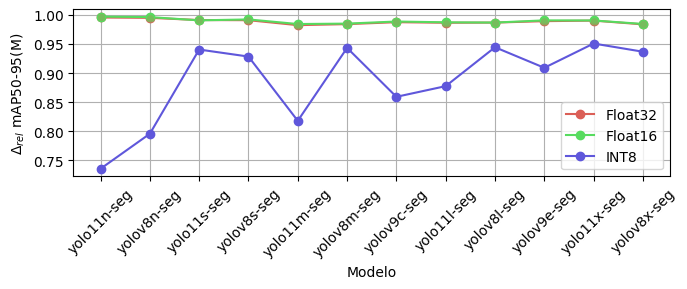

In [48]:
# TODO: Datos importantes!!!
figuras_yolo_format_ft_diffm = [plot_metric(**plot_dict_yolo_format_ft_diffm[1]), plot_metric(**plot_dict_yolo_format_ft_diffm[3]), plot_metric(**plot_dict_yolo_format_ft_diffm[5])]

### Con gráficos - Caso sin Transfer Learning (con outliers)

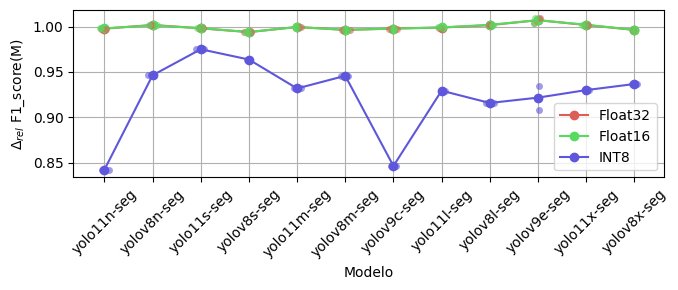

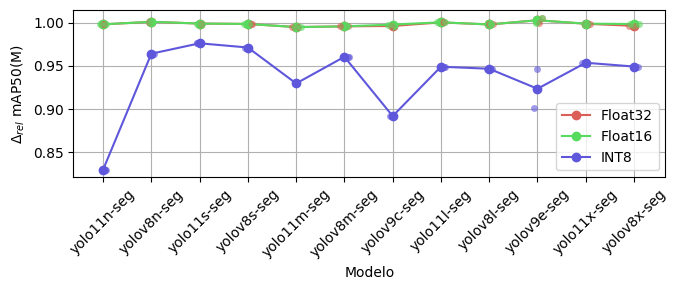

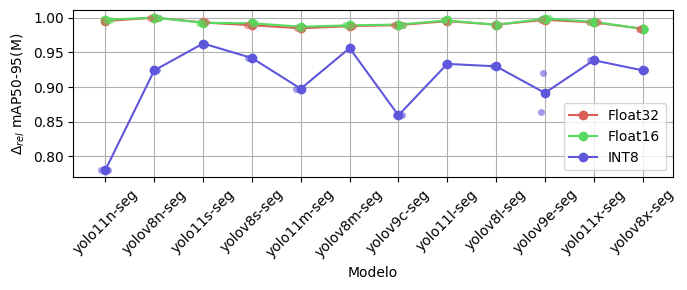

In [49]:
figuras_yolo_format_fl_diffm = [plot_metric(**plot_dict_yolo_format_fl_diffm[1]), plot_metric(**plot_dict_yolo_format_fl_diffm[3]), plot_metric(**plot_dict_yolo_format_fl_diffm[5])]

### Con gráficos - Caso con Transfer Learning (con outliers)

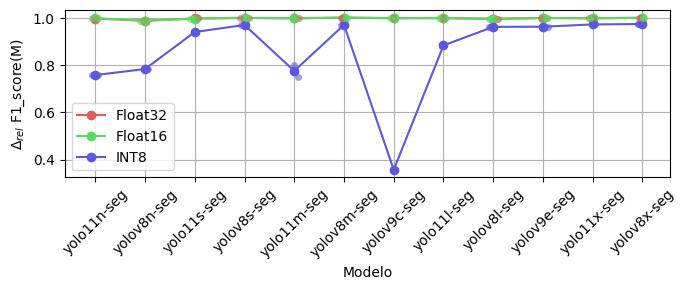

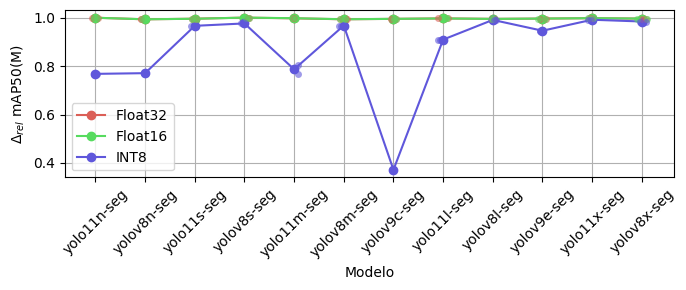

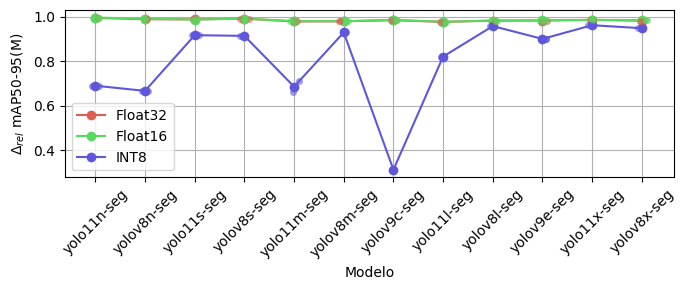

In [50]:
figuras_yolo_format_tl_diffm = [plot_metric(**plot_dict_yolo_format_tl_diffm[1]), plot_metric(**plot_dict_yolo_format_tl_diffm[3]), plot_metric(**plot_dict_yolo_format_tl_diffm[5])]

### Efecto del Transfer Learning al realizar cambio de formato a TensorRT

In [51]:
datagram = [mean_diff_m_by_TL]
datagrams = [mean_diff_m_by_TL, mean_diff_m_by_TL[mean_diff_m_by_TL["Outlier"]==False], mean_diff_m_by_TL[mean_diff_m_by_TL["Outlier"]==True]]

group = ["Format"]
groups = ["Format", "Format", "Format", "Format"]
metrics = ["F1_score(M)", "mAP50(M)", "mAP50-95(M)"]
labels = ["Promedio", "Sin outliers", " Con outliers"]
xlabel = "Formato de exportación"
ylabel = [r"$\Delta_{rel}$ F1_score(M)", r"$\Delta_{rel}$ mAP50(M)", r"$\Delta_{rel}$ mAP50-95(M)"]
title = None #"Factor de mejora de usar Transfer Learning."

order = ["Pytorch",  "TensorRT-F32", "TensorRT-F16", "TensorRT-INT8"]
label = ["Promedio"]

plot_dict_yolo_TransferLearning_diffm = crear_lista_diccionarios(datagram, datagrams, group, groups, metrics, label, labels, order, xlabel, ylabel, title)

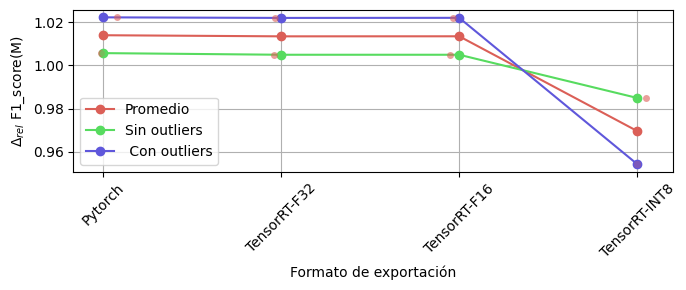

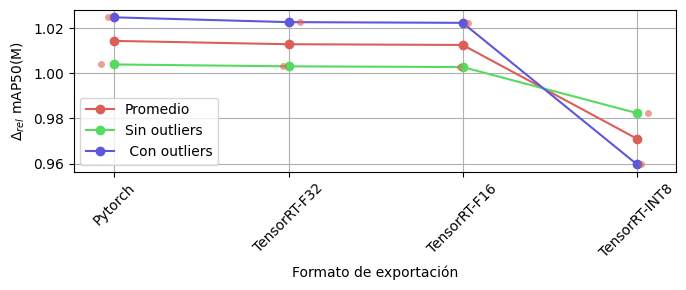

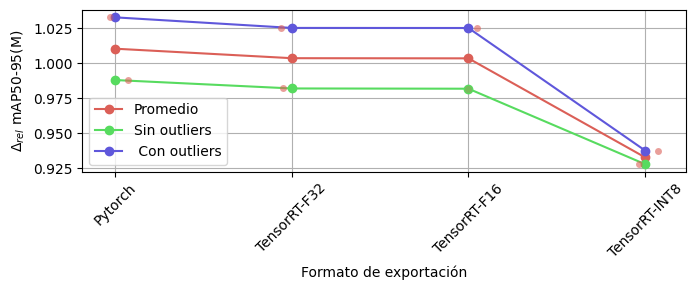

In [52]:
# TODO: Datos importantes!!!
# delta = transfer_learning / Normal
figuras_yolo_TransferLearning_diffm = [plot_metric(**plot_dict_yolo_TransferLearning_diffm[1]), plot_metric(**plot_dict_yolo_TransferLearning_diffm[3]), plot_metric(**plot_dict_yolo_TransferLearning_diffm[5])]

## Conclusiones sobre el efecto de la exportación:
1) A diferencia de lo que se pensaba en un incio, el tamaño del modelo no tiene mucho efecto en la caida del rendimiento del mismo al realizarce exportación en TensorRT. Esto puede que se deba a que el dataset es pequeño o quizás sea así en general.
2) Se apreció anteriormente que el optimizador si afecta en la caida de rendimiento con exportación con TensorRT, siendo SGD el que menor caida tiene en promedio. Esto se vió antes pero se aclara aquí nuevamente.
3) Se observa que el uso de transfer learning si tiene un efecto en la calidad del modelo al exportarse, siendo los entrenamientos sin transfer learning (sin congelar capas) el que mejores resultados da (menor caida en rendimiento), por ende debiese preferirse el entrenamiento de esta forma.

## Comparar YOLOv8 con YOLO11

### Tablas comparativas - Caso simple

In [53]:
# Comparación simple (sin diferencias)
df_yolov8 = df_updated.loc[df_updated["Model"].isin(orden_yolov8)].copy()
df_yolo11 = df_updated.loc[df_updated["Model"].isin(orden_yolo11)].copy()

# Reemplazar los valores en la columna "Model"
yolo_sizes = ["YOLOn", "YOLOs", "YOLOm", "YOLOl", "YOLOx"]
mapping_yolov8 = dict(zip(orden_yolov8, yolo_sizes))
mapping_yolo11 = dict(zip(orden_yolo11, yolo_sizes))
df_yolov8["Model"] = df_yolov8["Model"].replace(mapping_yolov8)
df_yolo11["Model"] = df_yolo11["Model"].replace(mapping_yolo11)

# Crear tablas comparativas
extra_conditions_1 = {"Format": ["Pytorch"], "TransferLearning": [False]}
extra_conditions_2 = {"Format": ["Pytorch"], "TransferLearning": [True]}
extra_conditions_3 = {"Format": ["TensorRT-INT8"], "TransferLearning": [False]}
extra_conditions_4 = {"Format": ["TensorRT-INT8"], "TransferLearning": [True]}
mean_yolov8_py_fl, mean_yolov9_py_fl, mean_yolo11_py_fl = crear_tabla_promedios_modelos_yolo(df_updated, extra_conditions_1)
mean_yolov8_py_tl, mean_yolov9_py_tl, mean_yolo11_py_tl = crear_tabla_promedios_modelos_yolo(df_updated, extra_conditions_2)
mean_yolov8_int8_fl, mean_yolov9_int8_fl, mean_yolo11_int8_fl = crear_tabla_promedios_modelos_yolo(df_updated, extra_conditions_3)
mean_yolov8_int8_tl, mean_yolov9_int8_tl, mean_yolo11_int8_tl = crear_tabla_promedios_modelos_yolo(df_updated, extra_conditions_4)

In [54]:
print("Resultados promedios y máximos por modelo. En formato Pytorch e ignorando Transfer Learning")
pd.concat([mean_yolov8_py_fl, pd.DataFrame([mean_yolov8_py_fl.select_dtypes(include='number').mean()]).assign(Model="YOLOv8"),
           mean_yolo11_py_fl, pd.DataFrame([mean_yolo11_py_fl.select_dtypes(include='number').mean()]).assign(Model="YOLO11")]).reset_index(drop=True)

Resultados promedios y máximos por modelo. En formato Pytorch e ignorando Transfer Learning


,Model,F1_score(M)_max,F1_score(M)_mean,F1_score(M)_std,mAP50(M)_max,mAP50(M)_mean,mAP50(M)_std,mAP50-95(M)_max,mAP50-95(M)_mean,mAP50-95(M)_std
0,yolov8n-seg,0.966823,0.952549,0.018230,0.970526,0.963955,0.005173,0.781918,0.773198,0.009754
1,yolov8s-seg,0.973211,0.967653,0.006413,0.977280,0.974353,0.003093,0.822257,0.810006,0.012148
2,yolov8m-seg,0.980555,0.973372,0.005588,0.986299,0.980116,0.004268,0.825671,0.819731,0.006913
3,yolov8l-seg,0.979347,0.966752,0.012153,0.993445,0.982922,0.016504,0.837653,0.826115,0.016791
4,yolov8x-seg,0.980003,0.975399,0.003071,0.981365,0.979097,0.002367,0.844794,0.829892,0.013050
5,YOLOv8,0.975988,0.967145,0.009091,0.981783,0.976088,0.006281,0.822459,0.811789,0.011731
6,yolo11n-seg,0.977739,0.962180,0.017831,0.986695,0.980825,0.005082,0.799653,0.782410,0.015727
7,yolo11s-seg,0.973712,0.967042,0.005551,0.991558,0.979274,0.010264,0.823575,0.804202,0.013963
8,yolo11m-seg,0.977192,0.971937,0.005176,0.989218,0.984245,0.006782,0.840589,0.816562,0.019701
9,yolo11l-seg,0.980456,0.972993,0.009384,0.984634,0.982127,0.002333,0.830353,0.816320,0.016131


In [55]:
print("Resultados promedios y máximos por modelo. En formato Pytorch y con Transfer Learning")
pd.concat([mean_yolov8_py_tl, pd.DataFrame([mean_yolov8_py_tl.select_dtypes(include='number').mean()]).assign(Model="YOLOv8"),
           mean_yolo11_py_tl, pd.DataFrame([mean_yolo11_py_tl.select_dtypes(include='number').mean()]).assign(Model="YOLO11")]).reset_index(drop=True)

Resultados promedios y máximos por modelo. En formato Pytorch y con Transfer Learning


,Model,F1_score(M)_max,F1_score(M)_mean,F1_score(M)_std,mAP50(M)_max,mAP50(M)_mean,mAP50(M)_std,mAP50-95(M)_max,mAP50-95(M)_mean,mAP50-95(M)_std
0,yolov8n-seg,0.971268,0.961036,0.017365,0.972636,0.967643,0.006805,0.751958,0.742561,0.008402
1,yolov8s-seg,0.980034,0.977806,0.003211,0.989500,0.985497,0.003932,0.809312,0.798236,0.007560
2,yolov8m-seg,0.979114,0.974648,0.003017,0.989725,0.987603,0.001748,0.822626,0.811046,0.009079
3,yolov8l-seg,0.986814,0.980352,0.005416,0.990080,0.988679,0.001859,0.833795,0.820902,0.009143
4,yolov8x-seg,0.974935,0.969958,0.008286,0.992228,0.988868,0.002648,0.829845,0.824218,0.006270
5,YOLOv8,0.978433,0.972760,0.007459,0.986834,0.983658,0.003398,0.809507,0.799393,0.008091
6,yolo11n-seg,0.966199,0.957238,0.007599,0.977591,0.975668,0.002009,0.745814,0.738892,0.004920
7,yolo11s-seg,0.973215,0.969925,0.003288,0.981729,0.973530,0.009334,0.788573,0.779715,0.007186
8,yolo11m-seg,0.986907,0.972939,0.015022,0.982804,0.980458,0.002465,0.833973,0.811717,0.015420
9,yolo11l-seg,0.977887,0.975129,0.001888,0.983512,0.981311,0.003106,0.830106,0.812738,0.015739


In [56]:
print("Resultados promedios y máximos por modelo. En formato TensorRT-INT8 e ignorando Transfer Learning")
pd.concat([mean_yolov8_int8_fl, pd.DataFrame([mean_yolov8_int8_fl.select_dtypes(include='number').mean()]).assign(Model="YOLOv8"),
           mean_yolo11_int8_fl, pd.DataFrame([mean_yolo11_int8_fl.select_dtypes(include='number').mean()]).assign(Model="YOLO11")]).reset_index(drop=True)

Resultados promedios y máximos por modelo. En formato TensorRT-INT8 e ignorando Transfer Learning


,Model,F1_score(M)_max,F1_score(M)_mean,F1_score(M)_std,mAP50(M)_max,mAP50(M)_mean,mAP50(M)_std,mAP50-95(M)_max,mAP50-95(M)_mean,mAP50-95(M)_std
0,yolov8n-seg,0.934029,0.901715,0.042289,0.941308,0.929323,0.009206,0.718378,0.714473,0.003944
1,yolov8s-seg,0.952675,0.932410,0.021221,0.961118,0.946348,0.017430,0.784397,0.762913,0.026495
2,yolov8m-seg,0.960333,0.920608,0.031202,0.970707,0.941410,0.026059,0.802250,0.784006,0.015620
3,yolov8l-seg,0.945200,0.885231,0.041964,0.966893,0.930649,0.031268,0.793966,0.768530,0.032403
4,yolov8x-seg,0.959512,0.913638,0.044388,0.964815,0.929474,0.041905,0.820887,0.767408,0.054644
5,YOLOv8,0.950350,0.910720,0.036213,0.960968,0.935441,0.025174,0.783976,0.759466,0.026621
6,yolo11n-seg,0.919832,0.811767,0.137513,0.949198,0.814573,0.167636,0.722121,0.611773,0.143795
7,yolo11s-seg,0.950600,0.942853,0.007327,0.974726,0.955850,0.012880,0.791406,0.774347,0.014781
8,yolo11m-seg,0.951578,0.905801,0.061317,0.943963,0.915218,0.037718,0.775238,0.733292,0.047182
9,yolo11l-seg,0.959886,0.904232,0.084279,0.964131,0.932028,0.049333,0.799014,0.761885,0.053212


In [57]:
print("Resultados promedios y máximos por modelo. En formato TensorRT-INT8 y con Transfer Learning")
pd.concat([mean_yolov8_int8_tl, pd.DataFrame([mean_yolov8_int8_tl.select_dtypes(include='number').mean()]).assign(Model="YOLOv8"),
           mean_yolo11_int8_tl, pd.DataFrame([mean_yolo11_int8_tl.select_dtypes(include='number').mean()]).assign(Model="YOLO11")]).reset_index(drop=True)

Resultados promedios y máximos por modelo. En formato TensorRT-INT8 y con Transfer Learning


,Model,F1_score(M)_max,F1_score(M)_mean,F1_score(M)_std,mAP50(M)_max,mAP50(M)_mean,mAP50(M)_std,mAP50-95(M)_max,mAP50-95(M)_mean,mAP50-95(M)_std
0,yolov8n-seg,0.773719,0.753628,0.028479,0.839426,0.746373,0.062925,0.563168,0.495752,0.047417
1,yolov8s-seg,0.978876,0.949187,0.027501,0.974725,0.962540,0.016506,0.777575,0.730333,0.045816
2,yolov8m-seg,0.964615,0.946238,0.014507,0.971965,0.955967,0.011549,0.772507,0.754376,0.025421
3,yolov8l-seg,0.953008,0.943767,0.010507,0.989620,0.980100,0.009668,0.796970,0.787048,0.010391
4,yolov8x-seg,0.951989,0.945507,0.007417,0.986149,0.973754,0.008509,0.790944,0.782299,0.008172
5,YOLOv8,0.924442,0.907666,0.017682,0.952377,0.923747,0.021831,0.740233,0.709962,0.027444
6,yolo11n-seg,0.759267,0.725838,0.055959,0.812421,0.749613,0.070522,0.556784,0.510214,0.048366
7,yolo11s-seg,0.933377,0.912520,0.020773,0.945681,0.941158,0.004994,0.744133,0.715754,0.025046
8,yolo11m-seg,0.799492,0.730926,0.095254,0.810834,0.752417,0.078676,0.618944,0.536786,0.089056
9,yolo11l-seg,0.906638,0.862197,0.044698,0.914780,0.892967,0.029309,0.704531,0.667801,0.038298


### Tablas comparativas - Por factor de mejora

In [58]:
# Parametros para comparar
columna = "Model"
opciones = [True, False]
casos_a_comparar_1 = ["yolov8n-seg", "yolo11n-seg"]
casos_a_comparar_2 = ["yolov8s-seg", "yolo11s-seg"]
casos_a_comparar_3 = ["yolov8m-seg", "yolo11m-seg"]
casos_a_comparar_4 = ["yolov8l-seg", "yolo11l-seg"]
casos_a_comparar_5 = ["yolov8x-seg", "yolo11x-seg"]

# Comparar por Modelo
resultados_yolon_fl = comparar_metricas(datagrama=df_updated, columna=columna, casos_a_comparar=casos_a_comparar_1)
resultados_yolos_fl = comparar_metricas(datagrama=df_updated, columna=columna, casos_a_comparar=casos_a_comparar_2)
resultados_yolom_fl = comparar_metricas(datagrama=df_updated, columna=columna, casos_a_comparar=casos_a_comparar_3)
resultados_yolol_fl = comparar_metricas(datagrama=df_updated, columna=columna, casos_a_comparar=casos_a_comparar_4)
resultados_yolox_fl = comparar_metricas(datagrama=df_updated, columna=columna, casos_a_comparar=casos_a_comparar_5)

mean_diff_yolon_fl, mean_diff_r_yolon_fl, mean_diff_m_yolon_fl, mean_diff_re_yolon_fl = crear_datagramas_filtrados(resultados_yolon_fl, "TransferLearning", opciones)
mean_diff_yolos_fl, mean_diff_r_yolos_fl, mean_diff_m_yolos_fl, mean_diff_re_yolos_fl = crear_datagramas_filtrados(resultados_yolos_fl, "TransferLearning", opciones)
mean_diff_yolom_fl, mean_diff_r_yolom_fl, mean_diff_m_yolom_fl, mean_diff_re_yolom_fl = crear_datagramas_filtrados(resultados_yolom_fl, "TransferLearning", opciones)
mean_diff_yolol_fl, mean_diff_r_yolol_fl, mean_diff_m_yolol_fl, mean_diff_re_yolol_fl = crear_datagramas_filtrados(resultados_yolol_fl, "TransferLearning", opciones)
mean_diff_yolox_fl, mean_diff_r_yolox_fl, mean_diff_m_yolox_fl, mean_diff_re_yolox_fl = crear_datagramas_filtrados(resultados_yolox_fl, "TransferLearning", opciones)

# Juntar en tablas comparativas
comparison_yolov8_to_yolo11 = crear_tabla_comparativa_para_modelos_yolo(mean_diff_m_yolon_fl, mean_diff_m_yolos_fl, mean_diff_m_yolom_fl, mean_diff_m_yolol_fl, mean_diff_m_yolox_fl, "Todos")
comparison_yolov8_to_yolo11_fl = crear_tabla_comparativa_para_modelos_yolo(mean_diff_m_yolon_fl, mean_diff_m_yolos_fl, mean_diff_m_yolom_fl, mean_diff_m_yolol_fl, mean_diff_m_yolox_fl, False)
comparison_yolov8_to_yolo11_tl = crear_tabla_comparativa_para_modelos_yolo(mean_diff_m_yolon_fl, mean_diff_m_yolos_fl, mean_diff_m_yolom_fl, mean_diff_m_yolol_fl, mean_diff_m_yolox_fl, True)

In [59]:
print("Mejora relativa entre YOLOv8 y YOLO11")
comparison_yolov8_to_yolo11

Mejora relativa entre YOLOv8 y YOLO11


,F1_score(M),mAP50(M),mAP50-95(M),fitness,preprocess,inference,postprocess,Model
0,0.987414,0.996281,0.989640,0.986640,1.014687,1.584330,1.125373,YOLOn
1,0.993847,0.994854,0.987953,0.982704,1.082618,0.985000,0.976114,YOLOs
2,0.978965,0.979062,0.965947,0.964237,1.003707,1.022675,0.997265,YOLOm
3,0.992515,0.987286,0.971955,0.974045,1.089346,0.837310,1.085582,YOLOl
4,0.997267,0.996486,0.995918,0.997443,0.971584,0.945224,1.056206,YOLOx


In [60]:
print("Mejora relativa entre YOLOv8 y YOLO11 (sin Transfer Learning)")
comparison_yolov8_to_yolo11_fl

Mejora relativa entre YOLOv8 y YOLO11 (sin Transfer Learning)


,F1_score(M),mAP50(M),mAP50-95(M),fitness,preprocess,inference,postprocess,Model
0,0.981665,0.980811,0.970931,0.966745,0.970735,2.006081,1.046521,YOLOn
1,1.004563,1.006602,0.999740,0.989472,1.106644,0.971878,1.017108,YOLOs
2,0.996378,0.995789,0.979476,0.978976,0.964023,1.017223,0.997835,YOLOm
3,1.008782,1.001417,0.992114,0.989925,1.163039,0.832835,1.136831,YOLOl
4,0.991501,1.001928,0.996226,0.997324,1.011652,0.942306,1.174022,YOLOx


In [61]:
print("Mejora relativa entre YOLOv8 y YOLO11 (con Transfer Learning)")
comparison_yolov8_to_yolo11_tl

Mejora relativa entre YOLOv8 y YOLO11 (con Transfer Learning)


,F1_score(M),mAP50(M),mAP50-95(M),fitness,preprocess,inference,postprocess,Model
0,0.993162,1.011751,1.008349,1.006534,1.058640,1.162578,1.204224,YOLOn
1,0.983130,0.983107,0.976166,0.975937,1.058592,0.998121,0.935120,YOLOs
2,0.960391,0.961220,0.951516,0.948515,1.046038,1.028491,0.996657,YOLOm
3,0.976248,0.973155,0.951796,0.958166,1.015653,0.841784,1.034333,YOLOl
4,1.003033,0.991044,0.995611,0.997561,0.931516,0.948143,0.938390,YOLOx


### Con gráficos - Comparación simple

#### Todos los casos

In [62]:
datagrama_cualquiera = [df_yolov8]
group = ["Model"]
groups = ["Model", "Model"]
metrics = ["F1_score(M)", "mAP50(M)", "mAP50-95(M)"]
label = ["YOLOv8"]
labels = ["YOLOv8", "YOLO11"]
xlabel = "Modelo"
ylabel = ["F1_score(M)", "mAP50(M)", "mAP50-95(M)"]
order = yolo_sizes

title = "YOLOv8 vs YOLO11"
datagramas_yolov8_yolo11 = [df_yolov8, df_yolo11]
plot_dict_yolo8vs11 = crear_lista_diccionarios(datagrama_cualquiera, datagramas_yolov8_yolo11, group, groups, metrics, label, labels, order, xlabel, ylabel, title)

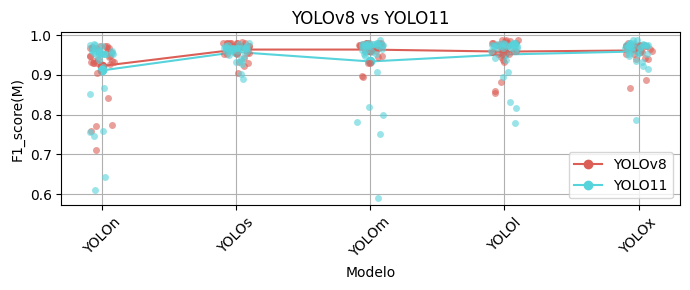

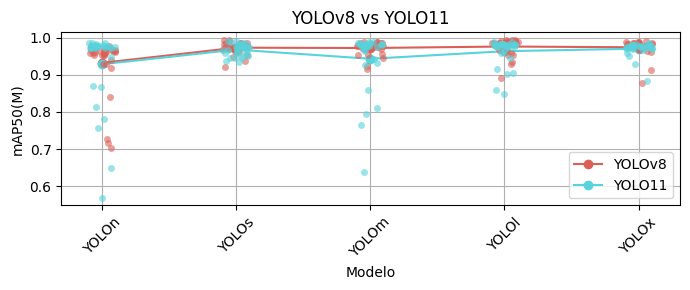

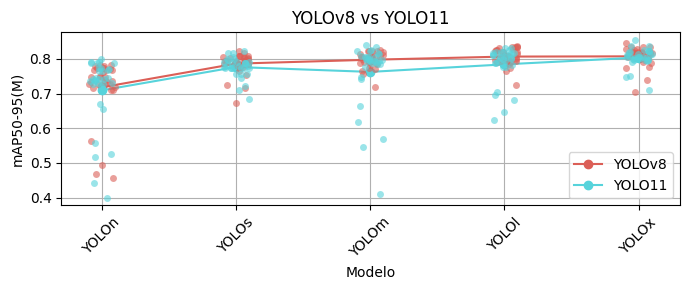

In [63]:
# TODO: Datos importantes!!!
figuras_yolov8vs11 = [plot_metric(**plot_dict_yolo8vs11[1]), plot_metric(**plot_dict_yolo8vs11[3]), plot_metric(**plot_dict_yolo8vs11[5])]

In [64]:
df_yolov8_to_show = df_yolov8.loc[(df_yolov8["TransferLearning"]==False) & (df_yolov8["Format"]=="TensorRT-INT8")]
df_yolo11_to_show = df_yolo11.loc[(df_yolo11["TransferLearning"]==False) & (df_yolo11["Format"]=="TensorRT-INT8")]

title = "YOLOv8 vs YOLO11 (Sin Transfer Learning y con exportación INT8)"
datagramas_yolov8_yolo11 = [df_yolov8_to_show, df_yolo11_to_show]
plot_dict_yolo8vs11_fl = crear_lista_diccionarios(datagrama_cualquiera, datagramas_yolov8_yolo11, group, groups, metrics, label, labels, order, xlabel, ylabel, title)

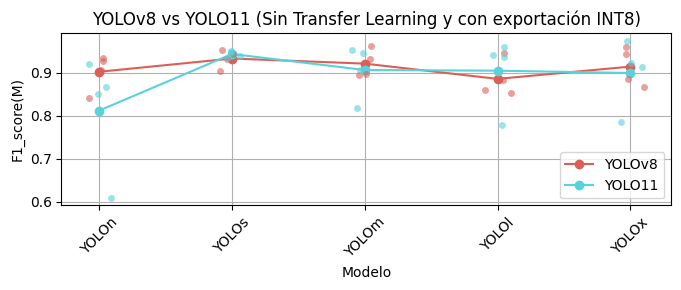

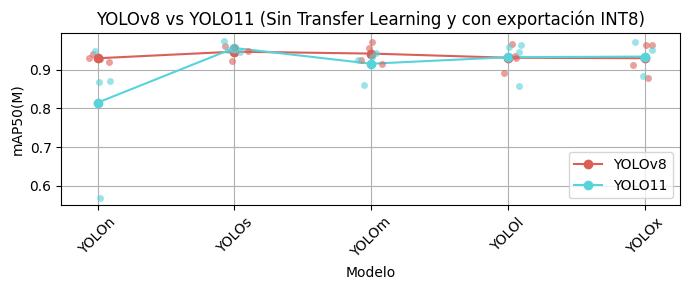

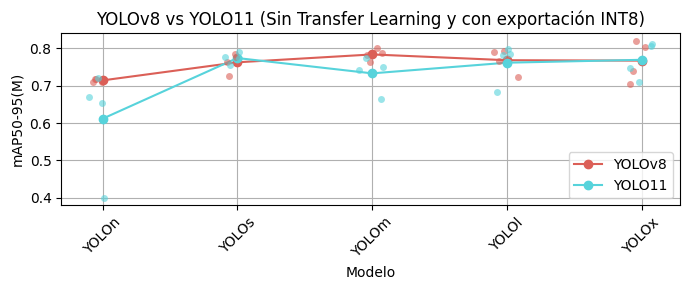

In [65]:
# TODO: Datos importantes!!!
figuras_yolov8vs11_fl = [plot_metric(**plot_dict_yolo8vs11_fl[1]), plot_metric(**plot_dict_yolo8vs11_fl[3]), plot_metric(**plot_dict_yolo8vs11_fl[5])]

### Con gráficos - Comparación factor de mejora

In [66]:
datagram_todos = [comparison_yolov8_to_yolo11]
datagramas_casos = [comparison_yolov8_to_yolo11, comparison_yolov8_to_yolo11_fl, comparison_yolov8_to_yolo11_tl]
group = ["Model"]
groups = ["Model", "Model", "Model"]
metrics = ["F1_score(M)", "mAP50(M)", "mAP50-95(M)"]
label = ["Promedio"]
labels = ["Promedio", "Con Transfer Learning", "Sin Transfer Learning"]
xlabel = "Modelo"
ylabel = [r"$\Delta_{rel}$ F1_score(M)", r"$\Delta_{rel}$ mAP50(M)", r"$\Delta_{rel}$ mAP50-95(M)"]
title = "Factor de mejora de YOLOv8 a YOLO11."
order = yolo_sizes

plot_dict_diff_yolo8vs11 = crear_lista_diccionarios(datagram_todos, datagramas_casos, group, groups, metrics, label, labels, order, xlabel, ylabel, title)

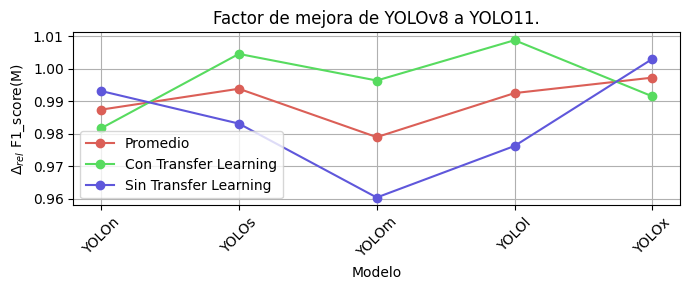

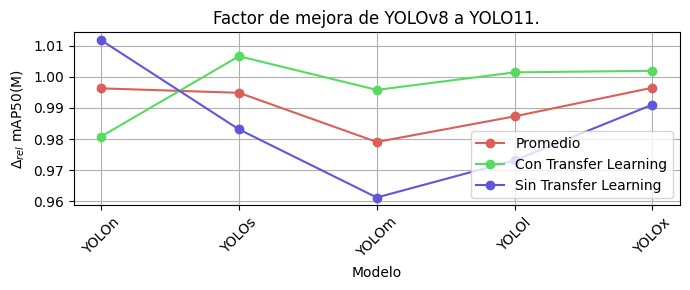

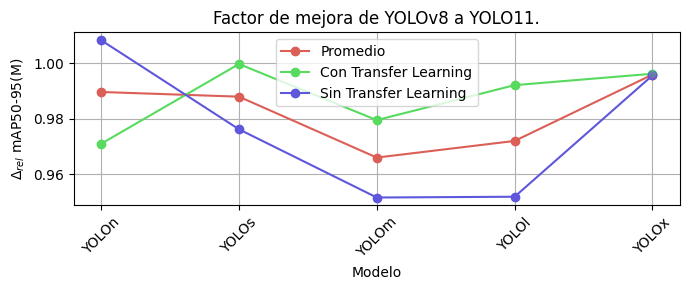

In [67]:
# TODO: Datos importantes!!!
# delta = (YOLO11 - YOLOv8) / YOLO11
figuras_diff_yolov8vs11 = [plot_metric(**plot_dict_diff_yolo8vs11[1]), plot_metric(**plot_dict_diff_yolo8vs11[3]), plot_metric(**plot_dict_diff_yolo8vs11[5])]

## Conclusiones de la comparación entre YOLOv8 y YOLO11:
1. YOLOv8 es en promedio ligeramente mejor que YOLO11, pero no siempre.
2. Parece ser que el entrenamiento con modelos medianos y grandes son ligeramente mejores pero estos tienen más caida de rendimiento al realizar exportación en TensoRT-INT8.

## Comparación según Dataset (Labels Only vs con imagenes de fondo)

### Tablas comparativas - caso simple

In [68]:
# Crear tablas comparativas
extra_conditions_1 = {"Format": ["Pytorch"]}
extra_conditions_2 = {"Format": ["TensorRT-INT8"]}
datasets_mean_py = crear_tabla_promedios_dataset(df_updated, ["Deepfish", "Deepfish_LO"], extra_conditions_1)
datasets_mean_int8 = crear_tabla_promedios_dataset(df_updated, ["Deepfish", "Deepfish_LO"], extra_conditions_2)

In [69]:
# TODO: Datos Importantes!!
print("Resultados promedios y máximos según versión del Dataset.")
pd.concat([datasets_mean_py.assign(Format="Pytorch"), datasets_mean_int8.assign(Format="TensorRT-INT8")]).reset_index(drop=True)

Resultados promedios y máximos según versión del Dataset.


,Dataset,F1_score(M)_max,F1_score(M)_mean,F1_score(M)_std,mAP50(M)_max,mAP50(M)_mean,mAP50(M)_std,mAP50-95(M)_max,mAP50-95(M)_mean,mAP50-95(M)_std,Format
0,Deepfish,0.991344,0.970418,0.009953,0.994753,0.980219,0.009104,0.853901,0.805987,0.030241,Pytorch
1,Deepfish_LO,0.986907,0.959847,0.064074,0.993445,0.970135,0.071104,0.844794,0.791847,0.083133,Pytorch
2,Deepfish,0.978876,0.875397,0.123354,0.989620,0.897609,0.113140,0.820887,0.709182,0.120049,TensorRT-INT8
3,Deepfish_LO,0.980014,0.843591,0.167792,0.984133,0.862165,0.182354,0.807764,0.666802,0.167375,TensorRT-INT8


### Tablas comparativas - mejora relativa

In [70]:
# Parametros para comparar
columna = "Dataset"
casos_a_comparar = ["Deepfish_LO", "Deepfish"]
opciones_1 = [True, False]
opciones_2 = ["Pytorch",  "TensorRT-F32", "TensorRT-F16", "TensorRT-INT8"]
opciones_3 = models_by_size

# Comparar por Dataset
resultados_dataset = comparar_metricas(datagrama=df_updated, columna=columna, casos_a_comparar=casos_a_comparar)
resultados_dataset_fl = comparar_metricas(datagrama=df_fl, columna=columna, casos_a_comparar=casos_a_comparar)
resultados_dataset_tl = comparar_metricas(datagrama=df_tl, columna=columna, casos_a_comparar=casos_a_comparar)

# Separar por diferentes casos
mean_diff_dataset_by_tl, mean_diff_r_dataset_by_tl, mean_diff_m_dataset_by_tl, mean_diff_re_dataset_by_tl = crear_datagramas_filtrados(resultados_dataset, "TransferLearning", opciones_1)
mean_diff_dataset_by_format, mean_diff_r_dataset_by_format, mean_diff_m_dataset_by_format, mean_diff_re_dataset_by_format = crear_datagramas_filtrados(resultados_dataset, "Format", opciones_2)
mean_diff_dataset_by_model, mean_diff_r_dataset_by_model, mean_diff_m_dataset_by_model, mean_diff_re_dataset_by_model = crear_datagramas_filtrados(resultados_dataset, "Model", opciones_3)


In [71]:
print("Mejora relativa del Dataset con imagenes de fondo, según uso de Transfer Learning.")
mean_diff_m_dataset_by_tl.loc[mean_diff_m_dataset_by_tl["Outlier"]==False,["F1_score(M)", "mAP50(M)", "mAP50-95(M)", "fitness", "TransferLearning"]].reset_index(drop=True)

Mejora relativa del Dataset con imagenes de fondo, según uso de Transfer Learning.


,F1_score(M),mAP50(M),mAP50-95(M),fitness,TransferLearning
0,1.007177,1.005753,1.017035,1.011502,True
1,1.013040,1.008481,1.013679,1.012417,False
2,1.010093,1.007110,1.015366,1.011957,Todos


In [72]:
# TODO: Resultados Importantes
print("Mejora relativa del Dataset con imagenes de fondo, según formato de exportación.")
mean_diff_m_dataset_by_format.loc[mean_diff_m_dataset_by_format["Outlier"]==False,["F1_score(M)", "mAP50(M)", "mAP50-95(M)", "fitness", "Format"]].reset_index(drop=True)

Mejora relativa del Dataset con imagenes de fondo, según formato de exportación.


,F1_score(M),mAP50(M),mAP50-95(M),fitness,Format
0,1.002497,1.000383,1.005384,1.002428,Pytorch
1,1.002634,1.000626,1.003173,1.000069,TensorRT-F32
2,1.002719,1.000614,1.002915,1.000048,TensorRT-F16
3,1.034050,1.028158,1.052354,1.047554,TensorRT-INT8
4,1.010093,1.007110,1.015366,1.011957,Todos


In [73]:
# TODO: Resultados Importantes
print("Mejora relativa del Dataset con imagenes de fondo, según el modelo.")
mean_diff_m_dataset_by_model.loc[mean_diff_m_dataset_by_model["Outlier"]==False,["F1_score(M)", "mAP50(M)", "mAP50-95(M)", "fitness", "Model"]].reset_index(drop=True)

Mejora relativa del Dataset con imagenes de fondo, según el modelo.


,F1_score(M),mAP50(M),mAP50-95(M),fitness,Model
0,1.031997,1.037910,1.047113,1.040121,yolo11n-seg
1,1.035803,1.014060,1.016982,1.014208,yolov8n-seg
2,0.993440,0.985146,0.994686,0.985598,yolo11s-seg
3,1.009829,1.006209,1.017499,1.009707,yolov8s-seg
4,1.015479,1.013459,1.026629,1.020732,yolo11m-seg
5,0.994692,0.999929,1.007808,1.004910,yolov8m-seg
6,1.027096,1.015316,1.033245,1.040772,yolov9c-seg
7,1.010582,1.012976,1.024967,1.020807,yolo11l-seg
8,0.990465,0.988317,0.998920,0.995379,yolov8l-seg
9,1.008571,1.011124,1.017361,1.013643,yolov9e-seg


### Con gráficos - Comparación simple

In [74]:
datagram_todos = [df_updated]
datagramas_casos = [df_updated[df_updated["Dataset"]=="Deepfish"], df_updated[df_updated["Dataset"]=="Deepfish_LO"]]
group = ["Model"]
groups = ["Model", "Model"]
metrics = ["F1_score(M)", "mAP50(M)", "mAP50-95(M)"]
label = ["Promedio"]
labels = ["Con imagenes de fondo", "Sin imagenes de fondo"]
xlabel = "Modelo"
ylabel = [r"F1_score(M)", r"mAP50(M)", r"mAP50-95(M)"]
title = None # "Modelos entrenados con datasets con y sin imagenes de fondo"
order = models_by_size

plot_dict_datasets = crear_lista_diccionarios(datagram_todos, datagramas_casos, group, groups, metrics, label, labels, order, xlabel, ylabel, title)

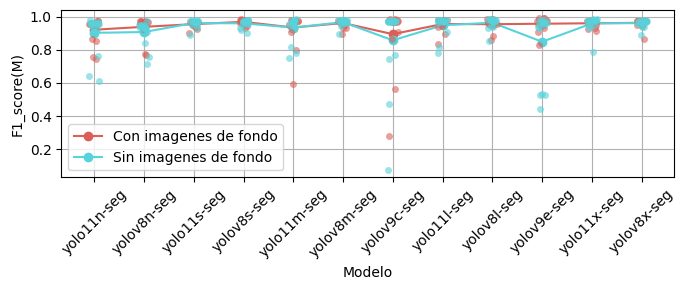

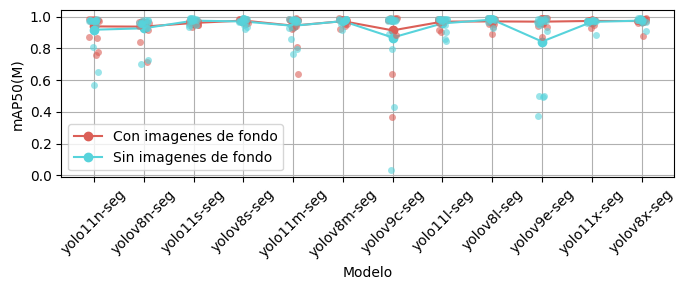

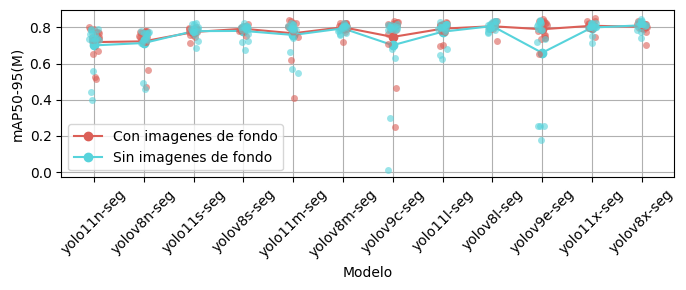

In [75]:
figuras_datasets = [plot_metric(**plot_dict_datasets[1]), plot_metric(**plot_dict_datasets[3]), plot_metric(**plot_dict_datasets[5])]

### Con gráficos - Comparación factor de mejora

In [76]:
datagram_todos = [mean_diff_m_dataset_by_model[mean_diff_m_dataset_by_model["Outlier"]==False]]
datagramas_casos = [mean_diff_m_dataset_by_model, mean_diff_m_dataset_by_model[mean_diff_m_dataset_by_model["Outlier"]==True], mean_diff_m_dataset_by_model[mean_diff_m_dataset_by_model["Outlier"]==False]]
group = ["Model"]
groups = ["Model", "Model", "Model"]
metrics = ["F1_score(M)", "mAP50(M)", "mAP50-95(M)"]
label = ["Promedio"]
labels = ["Promedio","Incluyendo Outliers", "Sin incluir Outliers"]
xlabel = "Modelo"
ylabel = [r"$\Delta_{rel}$ F1_score(M)", r"$\Delta_{rel}$ mAP50(M)", r"$\Delta_{rel}$ mAP50-95(M)"]
title = None #"Factor de mejora al añadir imagenes de fondo"
order = models_by_size

plot_dict_datasets_diff_model = crear_lista_diccionarios(datagram_todos, datagramas_casos, group, groups, metrics, label, labels, order, xlabel, ylabel, title, False)

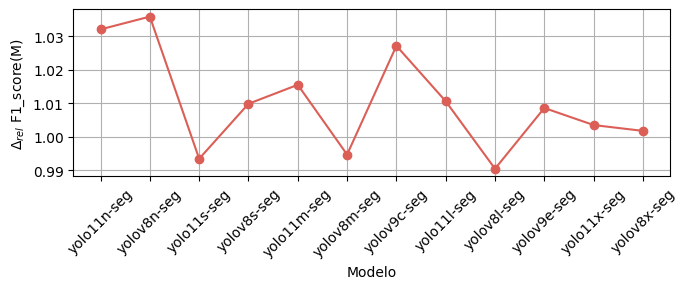

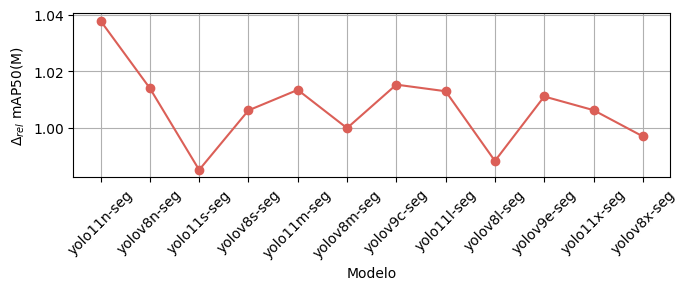

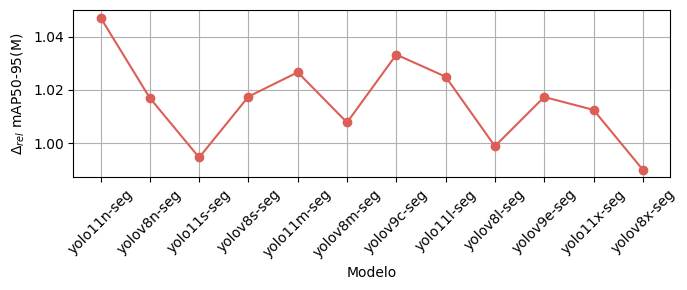

In [77]:
figuras_datasets_diff_model = [plot_metric(**plot_dict_datasets_diff_model[0]), plot_metric(**plot_dict_datasets_diff_model[2]), plot_metric(**plot_dict_datasets_diff_model[4])]

In [78]:
datagram_todos = [mean_diff_m_dataset_by_format[mean_diff_m_dataset_by_format["Outlier"]==False]]
datagramas_casos = [mean_diff_m_dataset_by_format, mean_diff_m_dataset_by_format[mean_diff_m_dataset_by_format["Outlier"]==True], mean_diff_m_dataset_by_format[mean_diff_m_dataset_by_format["Outlier"]==False]]
group = ["Format"]
groups = ["Format", "Format", "Format"]
metrics = ["F1_score(M)", "mAP50(M)", "mAP50-95(M)"]
label = ["Promedio"]
labels = ["Promedio","Incluyendo Outliers", "Sin incluir Outliers"]
xlabel = "Formato de Exportación"
ylabel = [r"$\Delta_{rel}$ F1_score(M)", r"$\Delta_{rel}$ mAP50(M)", r"$\Delta_{rel}$ mAP50-95(M)"]
title = None #"Factor de mejora al añadir imagenes de fondo"
order = ["Pytorch", "TensorRT-F32", "TensorRT-F16", "TensorRT-INT8"]

plot_dict_datasets_diff_format = crear_lista_diccionarios(datagram_todos, datagramas_casos, group, groups, metrics, label, labels, order, xlabel, ylabel, title)

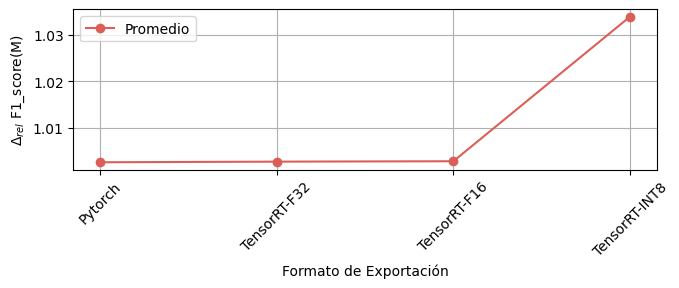

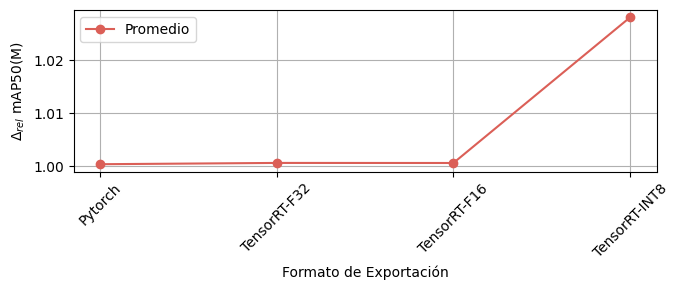

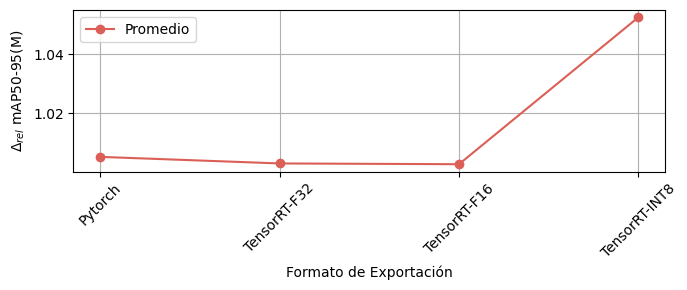

In [79]:
# TODO: IMPORTANTE!!
figuras_datasets_diff_format = [plot_metric(**plot_dict_datasets_diff_format[0]), plot_metric(**plot_dict_datasets_diff_format[2]), plot_metric(**plot_dict_datasets_diff_format[4])]

## Conclusiones sobre el tipo de Dataset:
1) El modelo entrenado con el Dataset que incluye imagenes de fondo (el normal) es consistentemente mejor que el que no tiene imagenes de fondo (Labels Only).
2) La diferencia se hace incluso un poco mayor al realizar la exportación con TensorRT en INT8.

## Tiempo de inferencia.

In [80]:
datagram_sin_usar = [df_pytorch]
datagramas_tiempos = [df_pytorch, df_tensor32, df_tensor16, df_tensor8]
group = ["Model"]
groups = ["Model", "Model", "Model", "Model"]
metrics = ["inference", "total_time", "FPS", "FPS_total"]
xlabel = "Modelo"
ylabel = ["Tiempo de inferencia (ms)", "Tiempo total (ms)", "Frecuencia de inferencia (FPS)", "Frecuencia total (FPS)"]
order = models_by_size
label = ["Pytorch"]
labels = ["Pytorch", "Float32", "Float16", "INT8"]
title = None #"Velocidad del modelo"

plot_dict_datasets_time = crear_lista_diccionarios(datagram_sin_usar, datagramas_tiempos, group, groups, metrics, label, labels, order, xlabel, ylabel, title)

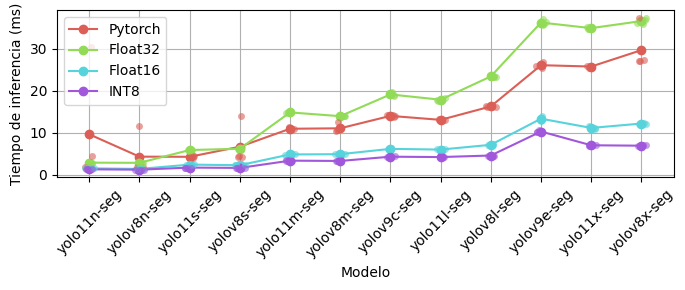

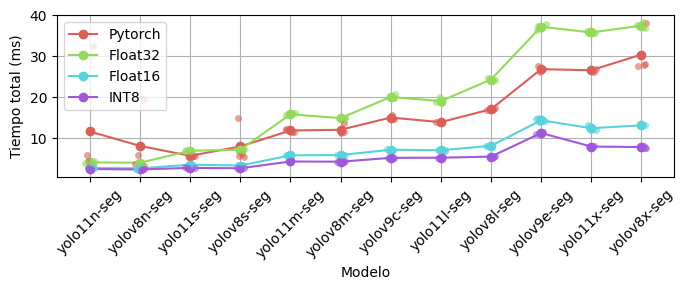

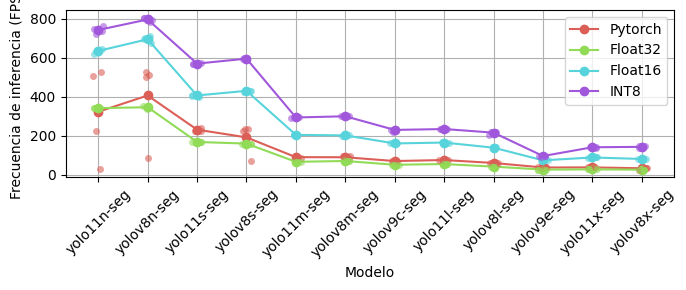

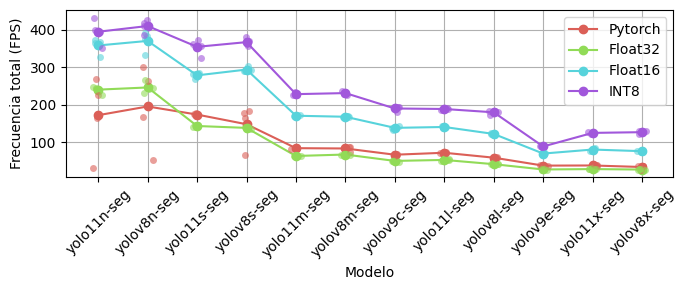

In [81]:
# TODO IMPORTANTE!!
figuras_datasets_time = [plot_metric(**plot_dict_datasets_time[1]), plot_metric(**plot_dict_datasets_time[3]),
                         plot_metric(**plot_dict_datasets_time[5]), plot_metric(**plot_dict_datasets_time[7])]

In [82]:
tablas_tiempo = crear_tablas_mejora_tiempos(df_updated, remove_outliers=True,
                                            outlier_method="zscore", z_thresh=2.5)

for formato, tabla in tablas_tiempo.items():
    print(f"\n{formato}")
    display(tabla)
    print(tabla[["Inference", "FPS"]].mean())


TensorRT-F32


,Models,Inference,Inference (Máx diff),FPS,FPS (Máx diff)
0,yolo11l-seg,1.365186,1.339202,-20.381562,-19.086216
1,yolo11m-seg,1.360039,1.295397,-24.274083,-20.212866
2,yolo11n-seg,1.199879,0.606605,-66.811281,133.984167
3,yolo11s-seg,1.377705,1.313619,-63.929521,-53.491977
4,yolo11x-seg,1.359942,1.339455,-10.301412,-9.840338
5,yolov8l-seg,1.437979,1.404571,-18.692316,-17.454686
6,yolov8m-seg,1.315357,1.294622,-22.549074,-21.081536
7,yolov8n-seg,1.444416,1.353250,-153.274917,-123.688772
8,yolov8s-seg,1.445111,1.370894,-70.914062,-59.546050
9,yolov8x-seg,1.354461,1.329004,-9.657355,-9.092955


Inference     1.367156
FPS         -40.858591
dtype: float64

TensorRT-F16


,Models,Inference,Inference (Máx diff),FPS,FPS (Máx diff)
0,yolo11l-seg,0.459936,0.447028,89.496963,93.212989
1,yolo11m-seg,0.452658,0.429681,111.026658,117.651195
2,yolo11n-seg,0.640019,0.324091,228.112997,430.875812
3,yolo11s-seg,0.574136,0.542446,173.035425,188.991242
4,yolo11x-seg,0.433589,0.426902,50.866505,51.989602
5,yolov8l-seg,0.440307,0.429926,78.049961,80.420790
6,yolov8m-seg,0.465436,0.459240,108.025320,109.331528
7,yolov8n-seg,0.717807,0.668157,196.150345,235.331946
8,yolov8s-seg,0.543053,0.516248,193.837489,210.699923
9,yolov8x-seg,0.453328,0.446824,44.524066,45.483608


Inference      0.510331
FPS          116.802271
dtype: float64

TensorRT-INT8


,Models,Inference,Inference (Máx diff),FPS,FPS (Máx diff)
0,yolo11l-seg,0.323039,0.315546,159.694616,162.554899
1,yolo11m-seg,0.317023,0.299598,197.935873,207.220559
2,yolo11n-seg,0.564175,0.283068,314.985521,523.260357
3,yolo11s-seg,0.412130,0.388106,333.362420,354.347722
4,yolo11x-seg,0.273156,0.267816,103.592600,106.154582
5,yolov8l-seg,0.283375,0.276519,155.315271,159.390521
6,yolov8m-seg,0.314839,0.310693,204.714303,208.416221
7,yolov8n-seg,0.627780,0.589571,295.760264,329.859086
8,yolov8s-seg,0.387467,0.371463,364.014435,372.411040
9,yolov8x-seg,0.257065,0.250638,106.749619,109.818407


Inference      0.371788
FPS          204.579659
dtype: float64


In [83]:
# Lista de tuplas con figuras y sus nombre de archivo
figuras_a_plotear = [
    (figuras_yolov8_f1score[0], "DeepFish-sizeComparison-YOLOv8-F1_score(M)"),
    (figuras_yolov8_map50[0], "DeepFish-sizeComparison-YOLOv8-mAP50(M)"),
    (figuras_yolov8_map5095[0], "DeepFish-sizeComparison-YOLOv8-mAP50-95(M)"),
    (figuras_yolov9_map5095[0], "DeepFish-sizeComparison-YOLOv9-mAP50-95(M)"),
    (figuras_yolo11_map5095[0], "DeepFish-sizeComparison-YOLO11-mAP50-95(M)"),
    (figuras_yolo_f1score[1], "DeepFish-TransferLearningComparison-YOLO-F1_score(M)"),
    (figuras_yolo_map50[1], "DeepFish-TransferLearningComparison-YOLO-mAP50(M)"),
    (figuras_yolo_map5095[1], "DeepFish-TransferLearningComparison-YOLO-mAP50-95(M)"),
    (figuras_yolo_format_map5095[1], "DeepFish-FormatComparison-YOLO-mAP50-95(M)"),
    (figuras_yolo__todos_int8_map5095[2], "DeepFish-TransferLearningComparison-YOLO-INT8-mAP50-95(M)"),
    (figuras_yolo_opt_simple[2], "DeepFish-OptimizerComparison-YOLO-mAP50-95(M)"),
    (figuras_yolo11_opt_diffm[3], "DeepFish-TransferLearningFactorMejora_Optimizer-YOLO-mAP50-95(M)"),
    (figuras_yolo_format_fl_diffm[2], "DeepFish-FormatFactorMejora_FullLearning-YOLO-mAP50-95(M)"),
    (figuras_yolo_format_tl_diffm[2], "DeepFish-FormatFactorMejora_TransferLearning-YOLO-mAP50-95(M)"),
    (figuras_yolo_TransferLearning_diffm[2], "DeepFish-TransferLearningFactorMejora-Format-mAP50-95(M)"),
    (figuras_datasets[2], "DeepFish-DatasetComparison-YOLO-mAP50-95(M)"),
    (figuras_datasets_diff_model[2], "DeepFish-DatasetFactorMejora-YOLO-mAP50-95(M)"),
    (figuras_datasets_diff_format[2], "DeepFish-DatasetFactorMejora-Format-mAP50-95(M)"),
    (figuras_datasets_time[0], "Deepfish-SpeedComparison-Time-inference"),
    (figuras_datasets_time[2], "Deepfish-SpeedComparison-FPS-inference"),
    (figuras_datasets_time[3], "Deepfish-SpeedComparison-FPS-total_time"),
]

# Guardar figuras
for figura, nombre in figuras_a_plotear:
    guardar_figura(figura, nombre, extension="pdf", directorio="figuras_finales")

# Conclusiones finales

1) Transfer Learning (TL):
    - Entrenar por TL para este dataset no implica una caida en el rendimiento, es mas, en promedio hacerlo entrega mejor rendimiento que un entrenamiento de todas las capas.
    - Entrenar por TL si implica de forma consistente una caida mayor en el rendimiento del modelo si se va a exportar con TensorRT-INT8.
        - Los modelos entrenados con TL al tener una mayor caida de remdimiento al exportar a TensorRT-INT8, incluso si empiezan mejor suelen en promedio terminar igual que un modelo entrenado sin TL.
        - Esto puede significar que si se tienen modelos iguales pre exportación, debiesen preferirse los entrenados sin TL. Se espera que esta situación ocurra al realizar una búsqueda de hiperparámetros, pues se utilizará solo el mejor de todos los casos.
2) Optimizador:
    - En promedio pero de forma consistente entrenar con SGD da mejores resultados que entrenar con AdamW.
    - AdamW tiene una mayor tendencia a realizar entrenamientos fallidos o divergentes.
    - AdamW tiene mayor sensibilidad a la taza de entrenamiento inicial y es muy fácil que diverga.
    - Los modelos entrenados con AdamW suelen tener una caida relativa mayor en su rendimiento al exportación con cuantización númerica INT8.
3) Efecto del tamaño del modelo (tamaño del archivo y número de parámetros):
    - Observando las métricas F1_Score y mAP50 indica que aumentar el tamaño del modelo no tiene un efectos positivos apreciables en el rendimiento de los modelos entrenados.
        - Es posible que esto se deba a que el dataset Deepfish es muy pequeño y simple y por lo tanto se llega a una cota superior de rendimiento que no se mejora con simplemente hacer el modelo más grande.
    - Para métricas más exigentes que las comunes, como lo es mAP50-95, un mayor tamaño de modelo si corresponde consistentemente con a un mejor rendimiento.
    - La caida de rendimiento al realizar cuantización númerica INT8 no parece ser muy afectada por el tamaño del modelo, solo si es muy pequeño (caso "n") y para algunos casos específicos como "yolo11m" y "yolov9c".
4) Comparación entre versiones de modelos:
    - Se observó que YOLOv8 es ligeramente superior a YOLO11.
    - YOLOv9c es consistentemente el peor al momento de exportarse con TensorRT-INT8.
5) Datasets:
    - Los modelos entrenados con un Dataset que incluye imagenes de fondo (caso normal) muestra mejor rendimiento que el entrenado solo con imagenes con instancias etiquetadas (Labels Only).
    - Cuando se utilizó YOLOv9 la diferencia entre utilizar y no utilizar imagenes de fondo se vuelve más pronunciada.

## Resolución
Realizar busqueda de hiperparámetros para modelos YOLOv8 y YOLO11 (l, x) y YOLOv9e; dataset normal; optimizador SGD; sin transfer learning.

# Mejores resultados finales

In [84]:
import os
import json
import numpy as np
import pandas as pd


def read_json(json_file) -> dict:
    with open(json_file, "r") as f:
        dictionary = json.load(f)
    return dictionary

def read_csv(csv_file):
    dataframe = pd.read_csv(csv_file)
    return dataframe

# Función para calcular el F1-score
def calculate_f1_score(precision, recall):
    # Evitar división por cero
    return np.where((precision + recall) > 0, 2 * (precision * recall) / (precision + recall), 0)

def combinar_datagramas(training_dfs: dict[str, pd.DataFrame]):
    # Crear una lista para almacenar los DataFrames con MultiIndex
    dfs = []
    for training_id, df in training_dfs.items():
        # Añadir el identificador del entrenamiento como columna temporal
        df = df.copy()
        df['tune_id'] = training_id
        # Establecer un MultiIndex con 'tune_id' y 'epoch'
        df = df.set_index(['tune_id', 'epoch'], drop=False)
        dfs.append(df)

    # Combinar todos los DataFrames en uno solo
    combined_df = pd.concat(dfs)
    combined_df = combined_df.rename(columns=lambda x: x.replace('metrics/', '') if 'metrics/' in x else x)

    # Renombrar el índice de épocas
    combined_df.index.names = ['tune_id', 'epoch']
    
    # Añadir F1_score
    combined_df['F1_score(B)'] = calculate_f1_score(combined_df['precision(B)'], combined_df['recall(B)'])
    combined_df['F1_score(M)'] = calculate_f1_score(combined_df['precision(M)'], combined_df['recall(M)'])

    # Reordenar las columnas para colocar F1_score entre recall y mAP50
    # Obtener la lista de columnas
    columns = combined_df.columns.tolist()

    # Encontrar las posiciones de las columnas relevantes
    pos_recall_B = columns.index('recall(B)')
    pos_recall_M = columns.index('recall(M)')

    # Extraer las columnas F1_score recién creadas
    f1_b = combined_df.pop('F1_score(B)')
    f1_m = combined_df.pop('F1_score(M)')

    # Insertar las columnas en las posiciones deseadas
    combined_df.insert(pos_recall_B + 1, 'F1_score(B)', f1_b)
    combined_df.insert(pos_recall_M + 1, 'F1_score(M)', f1_m)

    return combined_df

def return_best_tune(tunes_result: dict[str, pd.DataFrame], metrica: str) -> pd.DataFrame:
    best_cases = {}

    for tune, tunes_df in tunes_result.items():
        last_epochs_list = []
        best_epochs_list = []
        for tune_id in tunes_df["tune_id"].unique().tolist():
            last_epoch_idx = tunes_df.loc[tunes_df["tune_id"] == tune_id]["epoch"].idxmax()
            best_epoch_idx = tunes_df.loc[tunes_df["tune_id"] == tune_id][metrica].idxmax()
            last_epochs_list.append(last_epoch_idx)
            best_epochs_list.append(best_epoch_idx)
        
        last_epoch_tunes = tunes_df.loc[last_epochs_list]
        best_epoch_tunes = tunes_df.loc[best_epochs_list]

        max_index_last = last_epoch_tunes[metrica].idxmax()
        max_index_best = best_epoch_tunes[metrica].idxmax()

        # Obtener los detalles de los casos con el mayor valor
        max_row_last = tunes_df.loc[max_index_last, ["precision(M)", "recall(M)", "F1_score(M)", "mAP50(M)", "mAP50-95(M)", "epoch", "trial_id", "model"]]
        max_row_best = tunes_df.loc[max_index_best, ["precision(M)", "recall(M)", "F1_score(M)", "mAP50(M)", "mAP50-95(M)", "epoch", "trial_id", "model"]]

        # Crear un DataFrame con las filas como columnas, diferenciando last y best
        combined_df = pd.DataFrame({
            f'{tune}_last': max_row_last,
            f'{tune}_best': max_row_best
        })

        best_cases[tune] = combined_df

    # Combinar todos los DataFrames en uno solo
    best_cases_df = pd.concat(best_cases.values(), axis=1)

    # Ordenar las columnas por tune si es necesario
    #best_cases_df = best_cases_df[[col for col in sorted(best_cases_df.columns)]]
    
    return best_cases_df

def return_best_train(model_pairs, df, metrica):
    best_cases = pd.DataFrame()

    for model_pair in model_pairs:
        df_filtered = df.loc[df["Model"].isin(model_pair)]
        max_index = df_filtered[metrica].idxmax()
        # Obtener los detalles del caso con el mayor valor
        max_row = df_filtered.loc[max_index, ["precision(M)", "recall(M)", "F1_score(M)", "mAP50(M)", "mAP50-95(M)", "Model"]]
        best_cases[model_pair[0]] = max_row
    
    #best_cases = best_cases[sorted(best_cases.columns)]
    return best_cases

## Mejores resultados pre-tuning

In [85]:
model_pairs = [["yolov8l-seg", "yolov8l-seg*"], ["yolov8x-seg", "yolov8x-seg*"],
               ["yolov9e-seg", "yolov9e-seg*"], ["yolo11l-seg", "yolo11l-seg*"],
               ["yolo11x-seg", "yolo11x-seg*"]]

results_path_1 = "training/results_1.csv"
results_path_2 = "training/results_2.csv"

# Read both CSV files
df1 = pd.read_csv(results_path_1)   # Sin transfer Learning
df2 = pd.read_csv(results_path_2)   # Con transfer Learning

# Concatenate them into a single DataFrame
df = pd.concat([df1, df2], ignore_index=True)

best_f1score_train = return_best_train(model_pairs, df, "F1_score(M)")
best_map5095_train = return_best_train(model_pairs, df, "mAP50-95(M)")

In [86]:
best_f1score_train

,yolov8l-seg,yolov8x-seg,yolov9e-seg,yolo11l-seg,yolo11x-seg
precision(M),1.0,0.987157,0.987493,1.0,1.0
recall(M),0.974355,0.972952,0.999444,0.961662,0.97351
F1_score(M),0.987011,0.980003,0.993432,0.980456,0.986577
mAP50(M),0.985975,0.981365,0.994375,0.979905,0.976453
mAP50-95(M),0.807403,0.844794,0.823405,0.82608,0.810077
Model,yolov8l-seg*,yolov8x-seg,yolov9e-seg*,yolo11l-seg,yolo11x-seg*


In [87]:
best_map5095_train

,yolov8l-seg,yolov8x-seg,yolov9e-seg,yolo11l-seg,yolo11x-seg
precision(M),0.974473,0.987157,0.98496,0.985122,0.987003
recall(M),0.974684,0.972952,0.962025,0.974684,0.961263
F1_score(M),0.974578,0.980003,0.973357,0.979875,0.973963
mAP50(M),0.991529,0.981365,0.989339,0.984634,0.985225
mAP50-95(M),0.837653,0.844794,0.844153,0.830353,0.853901
Model,yolov8l-seg,yolov8x-seg,yolov9e-seg,yolo11l-seg,yolo11x-seg


## Mejores resultados post-tunning

In [88]:
# tune: model
casos_tune = {"tune": "yolov8l", "tune2": "yolov8x", "tune3": "yolov9e",
              "tune4": "yolo11l", "tune5": "yolo11x", "tune6": "yolov8l"}

tunes_path = "runs/detect"
tunes_result = {}

# Recorrer los distintos archivos tune
for tune in os.listdir(tunes_path):
    tune_path = os.path.join(tunes_path, tune)
    # Entrar en la carpeta tune con fecha
    for date in os.listdir(tune_path):
        tune_full_path = os.path.join(tune_path, date)
        # Crear un diccionario donde guardar los dataframes de cada entrenamiento
        training_dfs = {}

        # Recorrer todos los tune dentro de la carpeta
        for train in os.listdir(tune_full_path):
            train_path = os.path.join(tune_full_path, train)

            # Ignorar los archivos y solo revisar las carpetas
            if os.path.isdir(train_path):
                tune_id = "_".join(train.split("_")[2:4])
                result_path = os.path.join(train_path, "progress.csv")
                dataframe = read_csv(result_path)
                training_dfs[tune_id] = dataframe

        # Combinar los datagramas del diccionario en uno solo
        combined_df = combinar_datagramas(training_dfs)
        if tune in casos_tune.keys():
            combined_df["model"] = casos_tune[tune]
        else:
            combined_df["model"] = "Unknown"

    # Añadir el datagrama combinado al diccionario de tunes.
    tunes_result[tune] = combined_df

best_f1score_tune = return_best_tune(tunes_result, "F1_score(M)")
best_map5095_tune = return_best_tune(tunes_result, "mAP50-95(M)")

FileNotFoundError: [Errno 2] No such file or directory: 'runs/detect'

In [ ]:
best_f1score_tune

In [ ]:
best_map5095_tune

Se filtran los resultados solo de las epocas "last" y "best" pues estos son los checkpoints del modelo que obtenemos al entrenarlo con Ultralytics. "last" corresponde al  modelo al finalizar el entrenamiento y "best" es el checkpoint entrenado en el que se obtuvo el mejor puntaje mAP50(M).

Se selecciona el tune que demostró los mejores valores de mAP50-95(M)

    YOLOv8l: tune6 - e52e8_00034
    YOLOv8x: tune2 - 43e31_00007
    YOLOv9e: tune3 - 5ef43_00022
    YOLO11l: tune4 - 2e04e_00002
    YOLO11x: tune5 - c1a22_00000

In [ ]:
import os

def open_json(json_file):
    with open(json_file, 'r', encoding='utf-8') as archivo:
        tune_dict = json.load(archivo)
    return tune_dict

tunes_path = "runs/detect"
best_tunes_list = [
    {"model": "yolov8l-seg", "tune": "tune6", "id": "e52e8_00034"},
    {"model": "yolov8x-seg", "tune": "tune2", "id": "43e31_00007"},
    {"model": "yolov9c-seg", "tune": "tune3", "id": "5ef43_00022"},
    {"model": "yolo11l-seg", "tune": "tune4", "id": "2e04e_00002"},
    {"model": "yolo11x-seg", "tune": "tune5", "id": "c1a22_00000"},
]

for best_tune in best_tunes_list:
    tune_path = os.path.join(tunes_path, best_tune["tune"])
    for date in os.listdir(tune_path):
        tune_full_path = os.path.join(tune_path, date)
        for train in os.listdir(tune_full_path):
            train_path = os.path.join(tune_full_path, train)
            if best_tune["id"] in train_path:
                params_path = os.path.join(train_path, "params.json")
                params = open_json(params_path)
                print(params)

In [ ]:
tunes_path = "runs/detect"
default_params = {"epochs": 80, "single_cls": True, "cos_lr": True, "optimizer": "SGD"}
best_tunes_list = [
    {"model": "yolov8l-seg",
     "params": {
         "data": "/home/memorista01/tesis/datasets_yaml/Deepfish.yaml",
         "batch": 8,
         "lr0": 0.0030094320389691723,
         "lrf": 0.021028002627388707,
         "momentum": 0.8176950450060704,
         "warmup_epochs": 1.8128559556430095,
         "warmup_momentum": 0.4900346566989251,
         "weight_decay": 0.0009610879004378389}},
    {"model": "yolov8x-seg",
     "params": {
         "data": "/home/memorista01/tesis/datasets_yaml/Deepfish.yaml",
         "batch": 8,
         "lr0": 0.00618433824460782,
         "lrf": 0.284490917424955,
         "momentum": 0.7470405133584371,
         "warmup_epochs": 1.295316796581329,
         "warmup_momentum": 0.9081113388806424,
         "weight_decay": 0.0009698056459717375}},
    {"model": "yolov9c-seg",
     "params": {
         "data": "/home/memorista01/tesis/datasets_yaml/Deepfish.yaml",
         "batch": 6,
         "lr0": 0.006842631690244204,
         "lrf": 0.11984122900328371,
         "momentum": 0.7221154956852589,
         "warmup_epochs": 0.1917342587590004,
         "warmup_momentum": 0.6496749263513208,
         "weight_decay": 0.0006233910789756508}},
    {"model": "yolo11l-seg",
     "params": {
         "data": "/home/memorista01/tesis/datasets_yaml/Deepfish.yaml",
         "batch": 8,
         "lr0": 0.0035179713013480185,
         "lrf": 0.20811911273983605,
         "momentum": 0.7471144701086997,
         "warmup_epochs": 0.3112294727396592,
         "warmup_momentum": 0.5198800058587464,
         "weight_decay": 0.00046781008785355563}},
    {"model": "yolo11x-seg",
     "params": {
         "data": "/home/memorista01/tesis/datasets_yaml/Deepfish.yaml",
         "batch": 8,
         "lr0": 0.0028529805176369595,
         "lrf": 0.01920377656861268,
         "momentum": 0.7004853813748272,
         "warmup_epochs": 3.98955718449678,
         "warmup_momentum": 0.5421530648686753,
         "weight_decay": 0.0004405648826055806}},
]

for best_tune in best_tunes_list:
    model_name = best_tune["model"]
    params = {**default_params, **best_tune["params"]}
    print(params)

# Tabla de datos final